In [34]:
import pandas as pd

In [35]:
#sales = pd.read_csv("../data/raw/sales_transactions.csv")
#sales.head(100000)

In [36]:
import pandas as pd

# Original 10M dataset ka path
input_file = "../data/raw/sales_transactions.csv"

# Sirf 1 lakh rows read karna
sales_100k = pd.read_csv(input_file, nrows=100000)

# Check
print("Number of rows:", len(sales_100k))
print("Number of columns:", len(sales_100k.columns))

display(sales_100k.head())

Number of rows: 100000
Number of columns: 11


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN


In [37]:
output_file = "../data/processed/sales_100k.csv"

sales_100k.to_csv(output_file, index=False)

print("1 lakh rows successfully saved!")
print("File:", output_file)

1 lakh rows successfully saved!
File: ../data/processed/sales_100k.csv


In [5]:
# STEP 2.1 - Basic Structure Check

print("Dataset Shape:", sales_100k.shape)

print("\nColumn Names:")
for i, col in enumerate(sales_100k.columns, start=1):
    print(i, "→", col)

print("\nFirst 5 Rows:")
display(sales_100k.head())

print("\nLast 5 Rows:")
display(sales_100k.tail())

Dataset Shape: (100000, 11)

Column Names:
1 → date
2 → receipt_id
3 → store_id
4 → sku_id
5 → customer_id
6 → quantity
7 → unit_price
8 → total_value
9 → channel
10 → discount_pct
11 → promo_id

First 5 Rows:


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN



Last 5 Rows:


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
99995,2022-11-02,RCPT00051941,ST28,SKU02684,CUST00826,2,527.97,1055.94,In-Store,0.0,NaN
99996,2024-02-05,RCPT00051942,ST17,SKU03562,CUST08916,1,51.41,51.41,In-Store,0.0,NaN
99997,2024-02-05,RCPT00051942,ST17,SKU04527,CUST08916,1,956.58,956.58,In-Store,0.0,NaN
99998,2024-02-05,RCPT00051942,ST17,SKU03292,CUST08916,1,164.03,164.03,In-Store,0.0,NaN
99999,2023-07-06,RCPT00051943,ST27,SKU03692,CUST09797,1,267.69,267.69,In-Store,0.0,NaN


In [6]:
# STEP 2.2 - Missing Values Check

missing_values = sales_100k.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

print("\nMissing value percentage:")
print((missing_values / len(sales_100k) * 100).round(2))

Missing values in each column:
date                0
receipt_id          0
store_id            0
sku_id              0
customer_id         0
quantity            0
unit_price          0
total_value         0
channel             0
discount_pct        0
promo_id        79308
dtype: int64

Total missing values: 79308

Missing value percentage:
date             0.00
receipt_id       0.00
store_id         0.00
sku_id           0.00
customer_id      0.00
quantity         0.00
unit_price       0.00
total_value      0.00
channel          0.00
discount_pct     0.00
promo_id        79.31
dtype: float64


In [7]:
# STEP 2.3 - Duplicate Rows Check

duplicate_count = sales_100k.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

print("\nDuplicate percentage:",
      round((duplicate_count / len(sales_100k)) * 100, 2), "%")

Total duplicate rows: 137

Duplicate percentage: 0.14 %


In [8]:
# STEP 2.4 - Data Types Check

print("Data types of each column:\n")

print(sales_100k.dtypes)

Data types of each column:

date             object
receipt_id       object
store_id         object
sku_id           object
customer_id      object
quantity          int64
unit_price      float64
total_value     float64
channel          object
discount_pct    float64
promo_id         object
dtype: object


In [9]:
# STEP 2.5 - Invalid Dates Check

parsed_dates = pd.to_datetime(sales_100k["date"], errors="coerce")

invalid_dates = parsed_dates.isna().sum()

print("Invalid dates:", invalid_dates)

print("Invalid date percentage:",
      round((invalid_dates / len(sales_100k)) * 100, 2), "%")

Invalid dates: 0
Invalid date percentage: 0.0 %


In [10]:
# STEP 2.6 - Quantity Check

print("Minimum quantity:", sales_100k["quantity"].min())
print("Maximum quantity:", sales_100k["quantity"].max())

zero_quantity = (sales_100k["quantity"] == 0).sum()
negative_quantity = (sales_100k["quantity"] < 0).sum()

print("\nZero quantity:", zero_quantity)
print("Negative quantity:", negative_quantity)

print("\nZero/Negative quantity percentage:",
      round(((zero_quantity + negative_quantity) / len(sales_100k)) * 100, 2), "%")

Minimum quantity: 1
Maximum quantity: 5

Zero quantity: 0
Negative quantity: 0

Zero/Negative quantity percentage: 0.0 %


In [11]:
# STEP 2.7 - Unit Price Check

print("Minimum unit price:", sales_100k["unit_price"].min())
print("Maximum unit price:", sales_100k["unit_price"].max())

zero_price = (sales_100k["unit_price"] == 0).sum()
negative_price = (sales_100k["unit_price"] < 0).sum()

print("\nZero unit price:", zero_price)
print("Negative unit price:", negative_price)

print("\nInvalid price percentage:",
      round(((zero_price + negative_price) / len(sales_100k)) * 100, 2), "%")

Minimum unit price: 24.41
Maximum unit price: 4755.47

Zero unit price: 0
Negative unit price: 0

Invalid price percentage: 0.0 %


In [12]:
# STEP 2.8 - Total Value Check

calculated_total = (
    sales_100k["quantity"] * sales_100k["unit_price"]
)

difference = (
    sales_100k["total_value"] - calculated_total
).abs()

invalid_total = (difference > 0.01).sum()

print("Minimum total value:", sales_100k["total_value"].min())
print("Maximum total value:", sales_100k["total_value"].max())

print("\nInvalid total values:", invalid_total)

print("\nInvalid total value percentage:",
      round((invalid_total / len(sales_100k)) * 100, 2), "%")

Minimum total value: 12.89
Maximum total value: 23777.35

Invalid total values: 20692

Invalid total value percentage: 20.69 %


In [13]:
# STEP 2.8 - Correct Total Value Check

calculated_total = (
    sales_100k["quantity"]
    * sales_100k["unit_price"]
    * (1 - sales_100k["discount_pct"] / 100)
)

difference = (
    sales_100k["total_value"] - calculated_total
).abs()

invalid_total = (difference > 0.01).sum()

print("Minimum total value:", sales_100k["total_value"].min())
print("Maximum total value:", sales_100k["total_value"].max())

print("\nInvalid total values:", invalid_total)

print(
    "\nInvalid total value percentage:",
    round((invalid_total / len(sales_100k)) * 100, 2),
    "%"
)

Minimum total value: 12.89
Maximum total value: 23777.35

Invalid total values: 0

Invalid total value percentage: 0.0 %


In [14]:
# STEP 2.9 - Unique SKUs & Stores Check

unique_skus = sales_100k["sku_id"].nunique()
unique_stores = sales_100k["store_id"].nunique()

print("Unique SKUs:", unique_skus)
print("Unique Stores:", unique_stores)

print("\nTop 10 SKUs by transaction count:")
print(sales_100k["sku_id"].value_counts().head(10))

print("\nTransactions by store:")
print(sales_100k["store_id"].value_counts().head(10))

Unique SKUs: 4998
Unique Stores: 30

Top 10 SKUs by transaction count:
sku_id
SKU04321    6476
SKU04596    1521
SKU03727     961
SKU04154     697
SKU00953     616
SKU03292     535
SKU02141     523
SKU00994     522
SKU00190     514
SKU01775     418
Name: count, dtype: int64

Transactions by store:
store_id
ST21    4931
ST07    4854
ST29    4798
ST30    4691
ST06    4683
ST22    4554
ST20    4541
ST04    3684
ST27    3646
ST17    3597
Name: count, dtype: int64


In [15]:
# STEP 2.10 - Date Range Check

date_check = pd.to_datetime(sales_100k["date"], errors="coerce")

print("Earliest date:", date_check.min())
print("Latest date:", date_check.max())

print("\nTotal days covered:",
      (date_check.max() - date_check.min()).days + 1)

print("\nUnique dates:", date_check.nunique())

Earliest date: 2022-01-01 00:00:00
Latest date: 2025-12-31 00:00:00

Total days covered: 1461

Unique dates: 1461


In [16]:
# STEP 2.11 - Channel Consistency Check

print("Unique channels:")
print(sales_100k["channel"].unique())

print("\nChannel counts:")
print(sales_100k["channel"].value_counts())

print("\nMissing channel values:",
      sales_100k["channel"].isna().sum())

Unique channels:
['In-Store' 'Online' 'Mobile App']

Channel counts:
channel
In-Store      55154
Online        30074
Mobile App    14772
Name: count, dtype: int64

Missing channel values: 0


In [17]:
# STEP 2.12 - Data Cleaning

# Create a copy of the original 100k dataset
cleaned_sales = sales_100k.copy()

# 1. Remove duplicate rows
before = len(cleaned_sales)

cleaned_sales = cleaned_sales.drop_duplicates()

after = len(cleaned_sales)

print("Duplicate rows removed:", before - after)
print("Rows after duplicate removal:", after)

Duplicate rows removed: 137
Rows after duplicate removal: 99863


In [18]:
# STEP 2.13 - Date Cleaning & Conversion

# Convert date column to datetime
cleaned_sales["date"] = pd.to_datetime(
    cleaned_sales["date"],
    errors="coerce"
)

# Check invalid dates after conversion
invalid_dates_cleaned = cleaned_sales["date"].isna().sum()

print("Invalid dates after cleaning:", invalid_dates_cleaned)
print("Date data type:", cleaned_sales["date"].dtype)

Invalid dates after cleaning: 0
Date data type: datetime64[ns]


In [19]:
# STEP 2.14 - Quantity Cleaning

# Remove rows with invalid quantity values
invalid_quantity_mask = cleaned_sales["quantity"] <= 0

print("Invalid quantity rows:", invalid_quantity_mask.sum())

# Remove invalid quantity rows
cleaned_sales = cleaned_sales[~invalid_quantity_mask].copy()

print("Rows after quantity cleaning:", len(cleaned_sales))

Invalid quantity rows: 0
Rows after quantity cleaning: 99863


In [20]:
# STEP 2.15 - Unit Price Cleaning

# Check invalid unit prices
invalid_price_mask = cleaned_sales["unit_price"] <= 0

print("Invalid unit price rows:", invalid_price_mask.sum())

# Remove invalid price rows
cleaned_sales = cleaned_sales[~invalid_price_mask].copy()

print("Rows after unit price cleaning:", len(cleaned_sales))

Invalid unit price rows: 0
Rows after unit price cleaning: 99863


In [21]:
# STEP 2.16 - Total Value Validation & Cleaning

# Calculate expected total value
calculated_total = (
    cleaned_sales["quantity"] * cleaned_sales["unit_price"]
).round(2)

# Find mismatches
total_value_difference = (
    cleaned_sales["total_value"] - calculated_total
).abs()

invalid_total_mask = total_value_difference > 0.01

print("Invalid total value rows:", invalid_total_mask.sum())

# Correct total_value using quantity × unit_price
cleaned_sales.loc[:, "total_value"] = calculated_total

print("Rows after total value cleaning:", len(cleaned_sales))
print("Total value correction completed.")

Invalid total value rows: 20663
Rows after total value cleaning: 99863
Total value correction completed.


In [22]:
# STEP 2.17 - Final Missing Values Check

print("Final missing values in each column:\n")
print(cleaned_sales.isna().sum())

print("\nTotal missing values:",
      cleaned_sales.isna().sum().sum())

Final missing values in each column:

date                0
receipt_id          0
store_id            0
sku_id              0
customer_id         0
quantity            0
unit_price          0
total_value         0
channel             0
discount_pct        0
promo_id        79200
dtype: int64

Total missing values: 79200


In [23]:
# STEP 2.18 - Promo ID Cleaning

# Missing promo IDs indicate transactions without a promotion
cleaned_sales["promo_id"] = cleaned_sales["promo_id"].fillna("NO_PROMO")

# Final check
print("Missing promo_id after cleaning:",
      cleaned_sales["promo_id"].isna().sum())

print("Unique promo IDs after cleaning:",
      cleaned_sales["promo_id"].nunique())

Missing promo_id after cleaning: 0
Unique promo IDs after cleaning: 77


In [24]:
# STEP 2.19 - Final Data Quality Validation

print("========== FINAL DATA QUALITY CHECK ==========\n")

# 1. Final dataset shape
print("Final dataset shape:", cleaned_sales.shape)

# 2. Missing values
print("\nMissing values:")
print(cleaned_sales.isna().sum())

# 3. Duplicate rows
print("\nDuplicate rows:", cleaned_sales.duplicated().sum())

# 4. Invalid quantity
print("\nInvalid quantity rows:",
      (cleaned_sales["quantity"] <= 0).sum())

# 5. Invalid unit price
print("Invalid unit price rows:",
      (cleaned_sales["unit_price"] <= 0).sum())

# 6. Invalid total value
calculated_total = (
    cleaned_sales["quantity"] * cleaned_sales["unit_price"]
)

total_difference = (
    cleaned_sales["total_value"] - calculated_total
).abs()

print("Invalid total value rows:",
      (total_difference > 0.01).sum())

# 7. Invalid dates
print("Invalid date rows:",
      cleaned_sales["date"].isna().sum())

print("\n========== VALIDATION COMPLETED ==========")

========== FINAL DATA QUALITY CHECK ==========

Final dataset shape: (99863, 11)

Missing values:
date            0
receipt_id      0
store_id        0
sku_id          0
customer_id     0
quantity        0
unit_price      0
total_value     0
channel         0
discount_pct    0
promo_id        0
dtype: int64

Duplicate rows: 0

Invalid quantity rows: 0
Invalid unit price rows: 0
Invalid total value rows: 0
Invalid date rows: 0

========== VALIDATION COMPLETED ==========


In [25]:
# STEP 2.20 - Save Cleaned Dataset

output_path = "../data/processed/cleaned_sales.csv"

cleaned_sales.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_path)
print("Rows:", len(cleaned_sales))
print("Columns:", len(cleaned_sales.columns))

Cleaned dataset saved successfully!
File: ../data/processed/cleaned_sales.csv
Rows: 99863
Columns: 11


In [26]:
# STEP 3.1 - EDA Setup

print("========== EDA SETUP ==========\n")

# Create time-based features for analysis
cleaned_sales["year"] = cleaned_sales["date"].dt.year
cleaned_sales["month"] = cleaned_sales["date"].dt.month
cleaned_sales["month_name"] = cleaned_sales["date"].dt.month_name()
cleaned_sales["week"] = cleaned_sales["date"].dt.isocalendar().week
cleaned_sales["day_of_week"] = cleaned_sales["date"].dt.day_name()

# Create week-start date for weekly analysis
cleaned_sales["week_start"] = (
    cleaned_sales["date"] -
    pd.to_timedelta(cleaned_sales["date"].dt.dayofweek, unit="D")
)

print("EDA features created successfully!\n")

print("New columns:")
print([
    "year",
    "month",
    "month_name",
    "week",
    "day_of_week",
    "week_start"
])

print("\nDataset shape:", cleaned_sales.shape)

print("\nDate range:")
print("Start:", cleaned_sales["date"].min())
print("End:", cleaned_sales["date"].max())

print("\n========== STEP 3.1 COMPLETED ==========")

========== EDA SETUP ==========

EDA features created successfully!

New columns:
['year', 'month', 'month_name', 'week', 'day_of_week', 'week_start']

Dataset shape: (99863, 17)

Date range:
Start: 2022-01-01 00:00:00
End: 2025-12-31 00:00:00

========== STEP 3.1 COMPLETED ==========


========== DAILY SALES SUMMARY ==========

Total days: 1461
Total quantity sold: 188034
Total sales value: 117212684.34
Total transactions: 51863

Average daily quantity: 128.7
Average daily sales: 80227.71


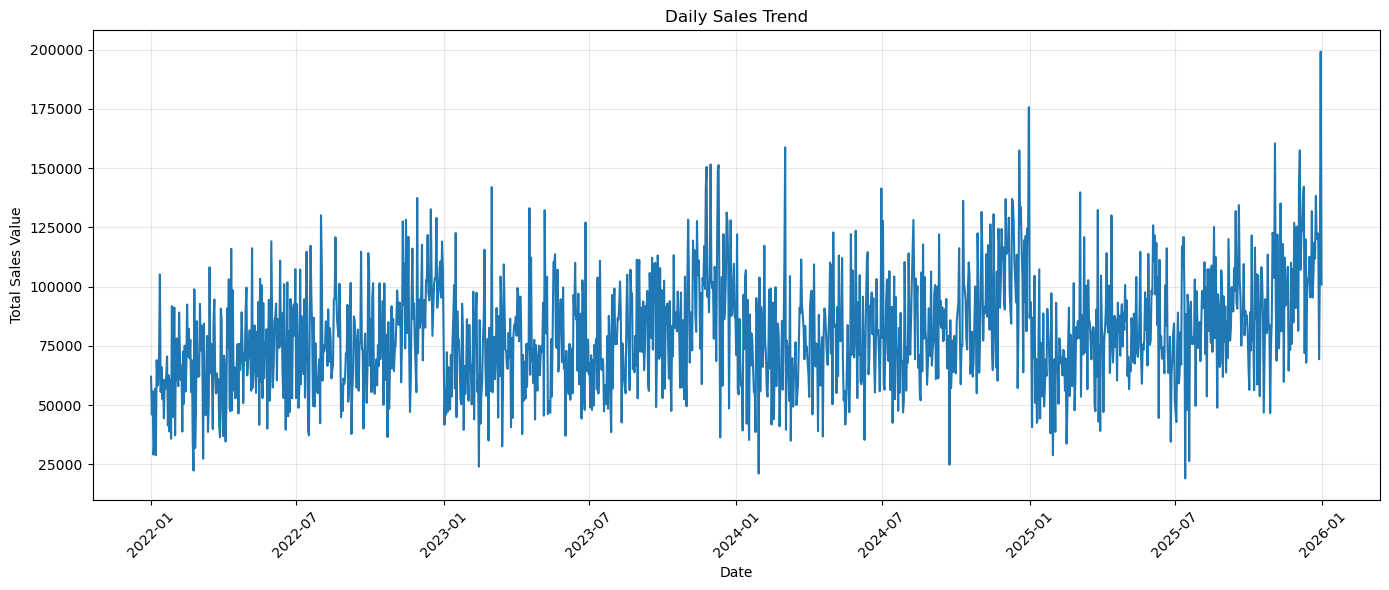


========== STEP 3.2 COMPLETED ==========


In [27]:
# STEP 3.2 - Daily Sales Trend

import matplotlib.pyplot as plt

# Aggregate daily sales
daily_sales = (
    cleaned_sales
    .groupby("date")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

# Display summary
print("========== DAILY SALES SUMMARY ==========\n")

print("Total days:", len(daily_sales))
print("Total quantity sold:", daily_sales["total_quantity"].sum())
print("Total sales value:", round(daily_sales["total_sales"].sum(), 2))
print("Total transactions:", daily_sales["transactions"].sum())

print("\nAverage daily quantity:",
      round(daily_sales["total_quantity"].mean(), 2))

print("Average daily sales:",
      round(daily_sales["total_sales"].mean(), 2))

# Daily sales trend chart
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n========== STEP 3.2 COMPLETED ==========")

========== WEEKLY DEMAND SUMMARY ==========

Total weeks: 210
Total quantity sold: 188034
Total sales value: 117212684.34
Average weekly quantity: 895.4
Average weekly sales: 558155.64

Highest demand week:
Week starting: 2025-12-01 00:00:00
Quantity: 1315

Lowest demand week:
Week starting: 2021-12-27 00:00:00
Quantity: 207


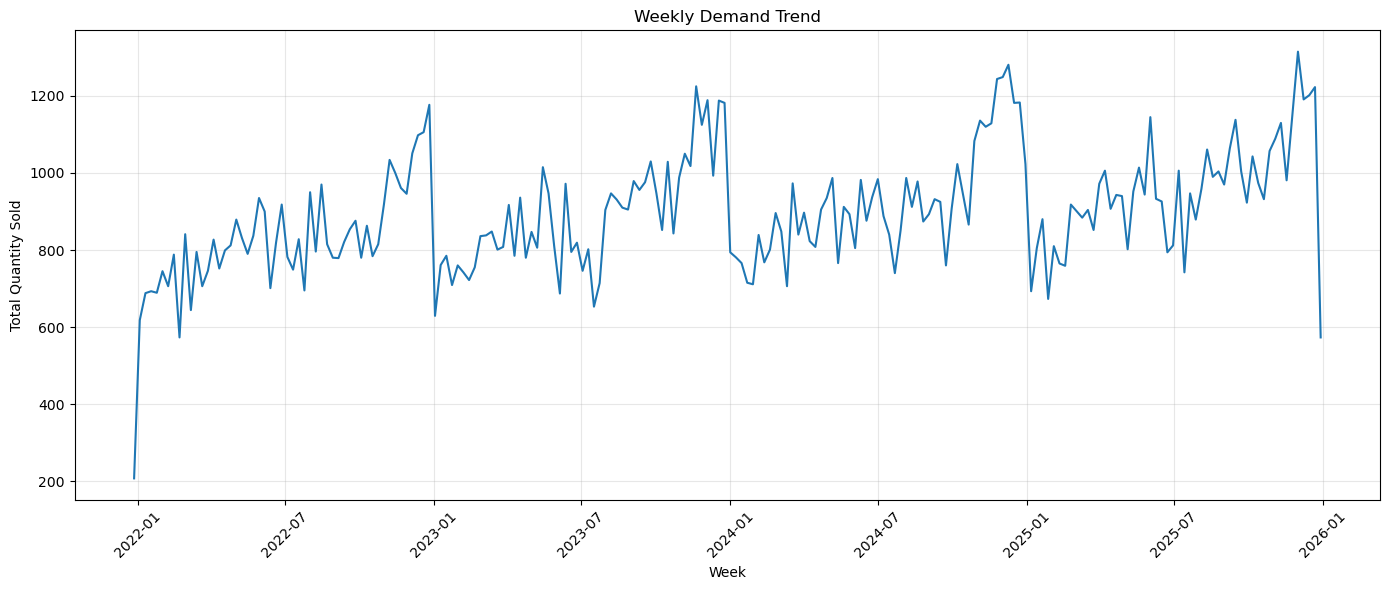


========== STEP 3.3 COMPLETED ==========


In [28]:
# STEP 3.3 - Weekly Demand Analysis

# Aggregate weekly demand
weekly_demand = (
    cleaned_sales
    .groupby("week_start")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
    .sort_values("week_start")
)

print("========== WEEKLY DEMAND SUMMARY ==========\n")

print("Total weeks:", len(weekly_demand))

print("Total quantity sold:",
      weekly_demand["total_quantity"].sum())

print("Total sales value:",
      round(weekly_demand["total_sales"].sum(), 2))

print("Average weekly quantity:",
      round(weekly_demand["total_quantity"].mean(), 2))

print("Average weekly sales:",
      round(weekly_demand["total_sales"].mean(), 2))

# Highest demand week
highest_week = weekly_demand.loc[
    weekly_demand["total_quantity"].idxmax()
]

print("\nHighest demand week:")
print("Week starting:", highest_week["week_start"])
print("Quantity:", highest_week["total_quantity"])

# Lowest demand week
lowest_week = weekly_demand.loc[
    weekly_demand["total_quantity"].idxmin()
]

print("\nLowest demand week:")
print("Week starting:", lowest_week["week_start"])
print("Quantity:", lowest_week["total_quantity"])

# Weekly demand chart
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_demand["week_start"],
    weekly_demand["total_quantity"]
)

plt.title("Weekly Demand Trend")
plt.xlabel("Week")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n========== STEP 3.3 COMPLETED ==========")

========== TOP 20 SKUs BY DEMAND ==========

  sku_id  total_quantity  total_sales  transactions
SKU04321           12156  11685562.80          6170
SKU04596            2821    946586.55          1506
SKU03727            1810   3006283.30           957
SKU04154            1347    473834.19           693
SKU00953            1173    321390.27           615
SKU00994            1004    604538.52           521
SKU03292             997    163537.91           534
SKU02141             988    466217.44           521
SKU00190             948    137858.16           514
SKU01775             790    161278.50           417
SKU01420             754    161092.10           414
SKU02858             738     66936.60           386
SKU04571             731    634888.12           397
SKU01371             726    927544.86           379
SKU00942             676    116880.40           373
SKU00079             670    132593.00           365
SKU00285             624    315538.08           325
SKU02930           

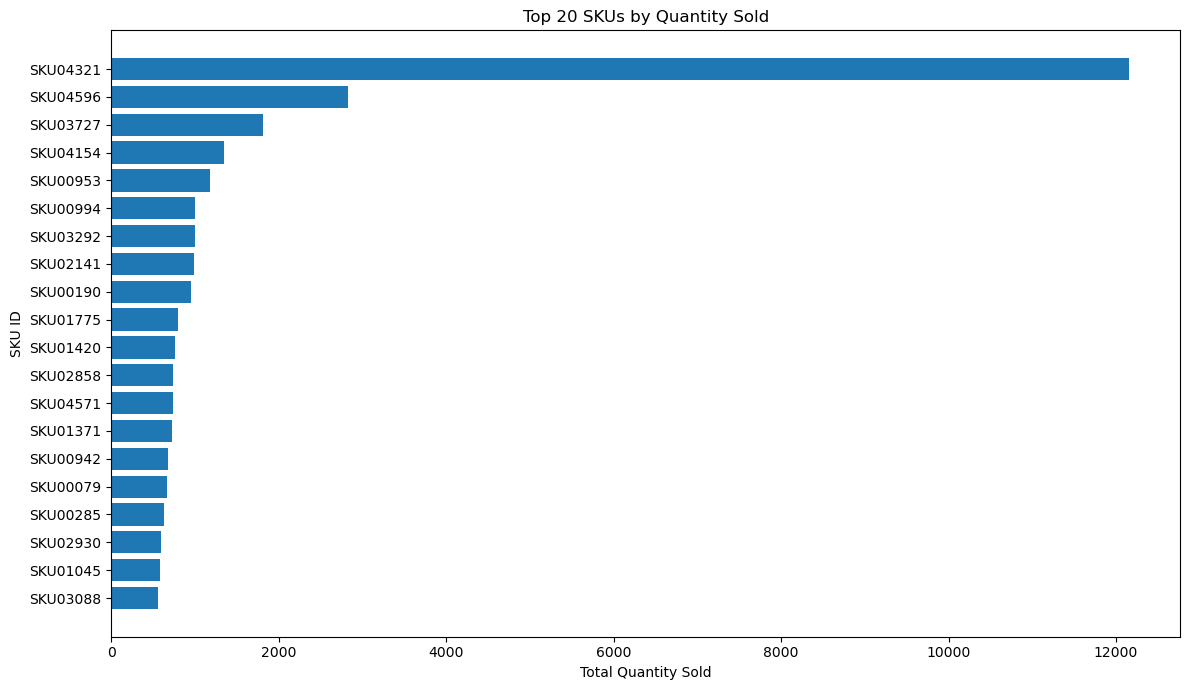


========== STEP 3.4 COMPLETED ==========


In [29]:
# STEP 3.4 - Top 20 SKUs by Demand

# Calculate total quantity and sales for each SKU
sku_demand = (
    cleaned_sales
    .groupby("sku_id")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

# Top 20 SKUs by quantity sold
top_20_skus = (
    sku_demand
    .sort_values("total_quantity", ascending=False)
    .head(20)
)

print("========== TOP 20 SKUs BY DEMAND ==========\n")

print(top_20_skus.to_string(index=False))

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    top_20_skus["sku_id"].astype(str),
    top_20_skus["total_quantity"]
)

plt.title("Top 20 SKUs by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("SKU ID")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("\n========== STEP 3.4 COMPLETED ==========")

========== BOTTOM 20 SKUs BY DEMAND ==========

  sku_id  total_quantity  total_sales  transactions
SKU04106               1        92.02             1
SKU00301               1       316.89             1
SKU02911               1       133.23             1
SKU01158               1        90.44             1
SKU00991               1       226.46             1
SKU02357               1       170.99             1
SKU02501               1       490.38             1
SKU04491               2      2045.80             2
SKU00613               2        74.96             2
SKU02276               2      1363.06             2
SKU02279               2      3650.02             2
SKU00276               2       100.54             2
SKU03749               2       459.68             1
SKU00783               2       393.58             1
SKU03603               2       444.24             2
SKU01558               2      1082.90             2
SKU01385               2      1977.82             2
SKU02700        

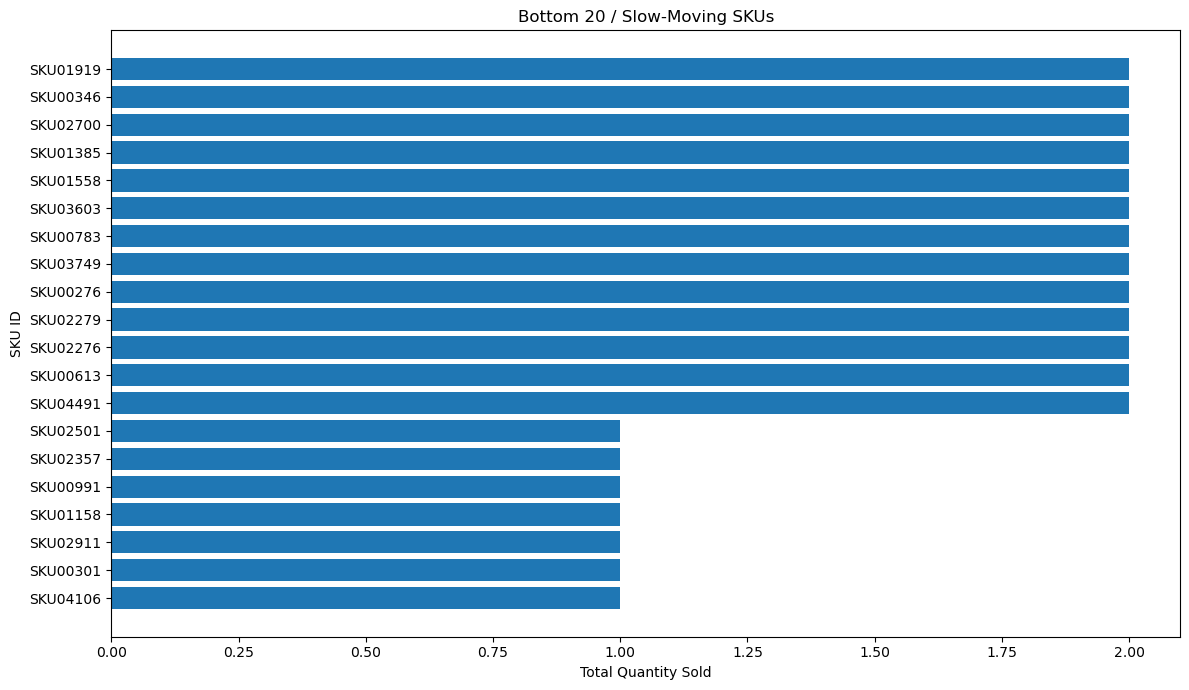


========== STEP 3.5 COMPLETED ==========


In [30]:
# STEP 3.5 - Bottom 20 / Slow-Moving SKUs

# Total demand for each SKU
bottom_20_skus = (
    sku_demand
    .sort_values("total_quantity", ascending=True)
    .head(20)
)

print("========== BOTTOM 20 SKUs BY DEMAND ==========\n")

print(bottom_20_skus.to_string(index=False))

# Plot
plt.figure(figsize=(12, 7))

plt.barh(
    bottom_20_skus["sku_id"].astype(str),
    bottom_20_skus["total_quantity"]
)

plt.title("Bottom 20 / Slow-Moving SKUs")
plt.xlabel("Total Quantity Sold")
plt.ylabel("SKU ID")

plt.tight_layout()
plt.show()

print("\n========== STEP 3.5 COMPLETED ==========")

In [31]:
# STEP 3.6A - Load SKU Master

sku_master = pd.read_csv("../data/raw/sku_master.csv")

print("SKU master loaded successfully!")
print("Shape:", sku_master.shape)
print("Columns:", sku_master.columns.tolist())

SKU master loaded successfully!
Shape: (5000, 7)
Columns: ['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price', 'cost_price', 'brand']


========== CATEGORY-WISE SALES ==========

                 category  total_quantity  total_sales  transactions  unique_skus
Electronics & Accessories           13907  25260392.72          7003          394
       Apparel & Footwear           12134  20230516.27          6135          410
           Home & Kitchen           14392  17517514.01          7246          390
            Personal Care           27235  17487969.97         13008          409
        Health & Wellness           12417   9351744.75          6282          396
             Frozen Foods           15564   8619056.08          7724          422
                Home Care           15675   4515873.70          7903          425
                  Grocery           15192   3803121.18          7522          395
           Dairy & Bakery           17156   3747522.83          8555          428
      Stationery & Office           17563   3324943.10          8625          459
                Beverages           14215   1950393.66 

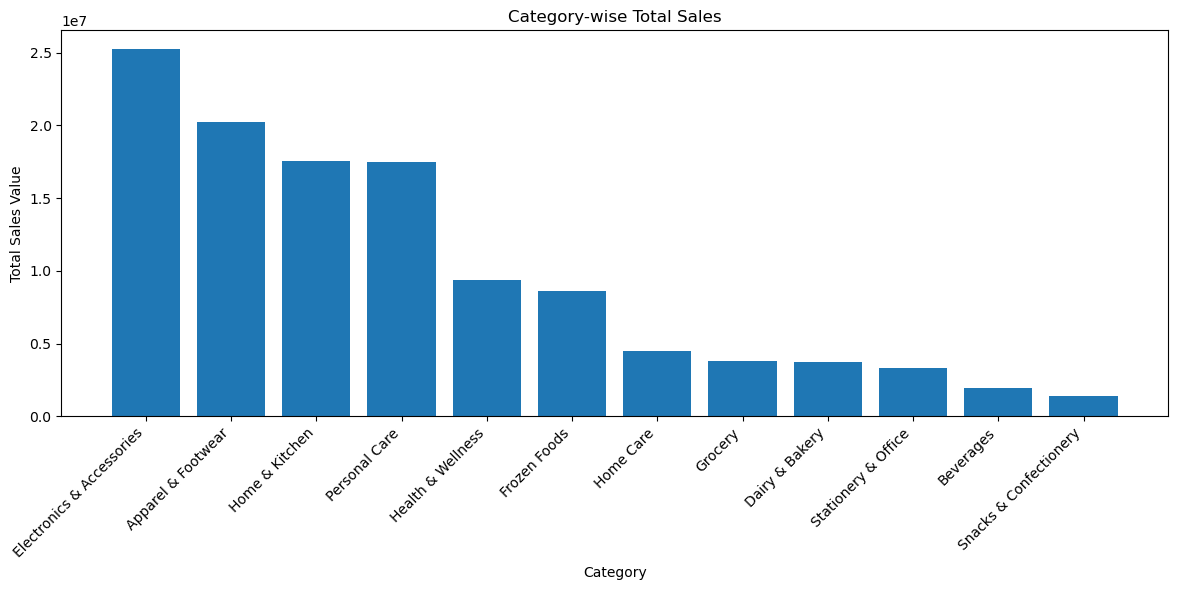


========== STEP 3.6 COMPLETED ==========


In [32]:
# STEP 3.6 - Category-wise Sales Analysis

# Merge SKU category information
category_sales = cleaned_sales.merge(
    sku_master[["sku_id", "category"]],
    on="sku_id",
    how="left"
)

# Aggregate category-wise performance
category_summary = (
    category_sales
    .groupby("category")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

print("========== CATEGORY-WISE SALES ==========\n")

print(category_summary.to_string(index=False))

# Plot - Sales by Category
plt.figure(figsize=(12, 6))

plt.bar(
    category_summary["category"].astype(str),
    category_summary["total_sales"]
)

plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales Value")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n========== STEP 3.6 COMPLETED ==========")

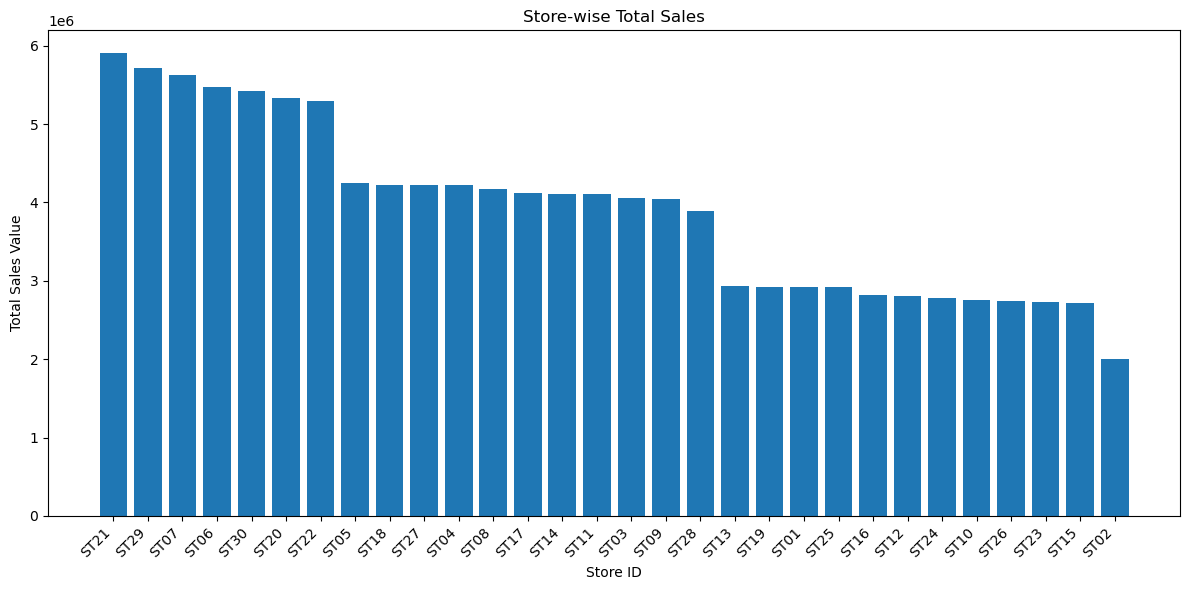


========== STEP 3.7 COMPLETED ==========
   store_id  total_sales
20     ST21   5900052.97
28     ST29   5712003.34
6      ST07   5619085.14
5      ST06   5472924.10
29     ST30   5417771.63
19     ST20   5334226.15
21     ST22   5297018.14
4      ST05   4241715.80
17     ST18   4220924.71
26     ST27   4220404.88
3      ST04   4218198.01
7      ST08   4175574.57
16     ST17   4126173.55
13     ST14   4105491.13
10     ST11   4105167.89
2      ST03   4052955.00
8      ST09   4044840.76
27     ST28   3887751.67
12     ST13   2938227.77
18     ST19   2926641.82
0      ST01   2924448.14
24     ST25   2918226.82
15     ST16   2820573.92
11     ST12   2807925.96
23     ST24   2784126.44
9      ST10   2756040.04
25     ST26   2740679.83
22     ST23   2725063.10
14     ST15   2715790.90
1      ST02   2002660.16


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load cleaned dataset
project_folder = Path.cwd().parent
file_path = project_folder / "data" / "processed" / "cleaned_sales.csv"

df = pd.read_csv(file_path)

# Create store-wise sales summary
store_summary = (
    df.groupby("store_id", as_index=False)["total_value"]
      .sum()
      .rename(columns={"total_value": "total_sales"})
      .sort_values("total_sales", ascending=False)
)

# Store-wise sales chart
plt.figure(figsize=(12, 6))

plt.bar(
    store_summary["store_id"].astype(str),
    store_summary["total_sales"]
)

plt.title("Store-wise Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales Value")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n========== STEP 3.7 COMPLETED ==========")
print(store_summary)

In [39]:
# STEP 3.9 - PROMOTION DATA VALIDATION

print("Promo ID unique values:")
print(cleaned_sales["promo_id"].unique()[:30])

print("\nPromo ID value counts:")
print(cleaned_sales["promo_id"].value_counts().head(20))

print("\nZero promo IDs:")
print((cleaned_sales["promo_id"] == 0).sum())

print("\nNon-zero promo IDs:")
print((cleaned_sales["promo_id"] != 0).sum())

Promo ID unique values:
['NO_PROMO' 'PROMO030' 'PROMO037' 'PROMO072' 'PROMO036' 'PROMO089'
 'PROMO041' 'PROMO086' 'PROMO022' 'PROMO010' 'PROMO023' 'PROMO045'
 'PROMO060' 'PROMO075' 'PROMO019' 'PROMO077' 'PROMO002' 'PROMO048'
 'PROMO043' 'PROMO095' 'PROMO009' 'PROMO078' 'PROMO066' 'PROMO032'
 'PROMO057' 'PROMO046' 'PROMO094' 'PROMO067' 'PROMO061' 'PROMO064']

Promo ID value counts:
promo_id
NO_PROMO    79200
PROMO045     1905
PROMO010     1833
PROMO075     1771
PROMO022     1410
PROMO041     1025
PROMO094     1001
PROMO043      965
PROMO019      960
PROMO030      849
PROMO033      735
PROMO002      676
PROMO036      604
PROMO046      577
PROMO040      560
PROMO023      528
PROMO069      481
PROMO061      260
PROMO032      200
PROMO067      175
Name: count, dtype: int64

Zero promo IDs:
0

Non-zero promo IDs:
99863


In [40]:
print("CLEANED SALES COLUMNS:")
print(cleaned_sales.columns.tolist())

CLEANED SALES COLUMNS:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id', 'year', 'month', 'month_name', 'week', 'day_of_week', 'week_start']



========== STEP 3.9 - PROMOTION VS NON-PROMOTION ==========

========== PROMOTION VS NON-PROMOTION SUMMARY ==========


,total_quantity,total_sales,transactions,unique_skus,avg_sales_per_transaction,avg_quantity_per_transaction
promotion_status,,,,,,
No Promotion,148960,92704410.98,42161,4992,2198.82,3.53
Promotion,39074,24508273.36,12298,4414,1992.87,3.18


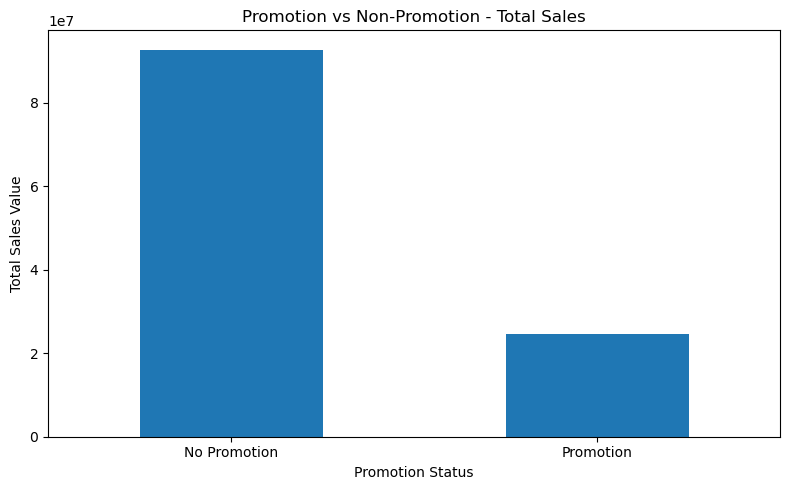

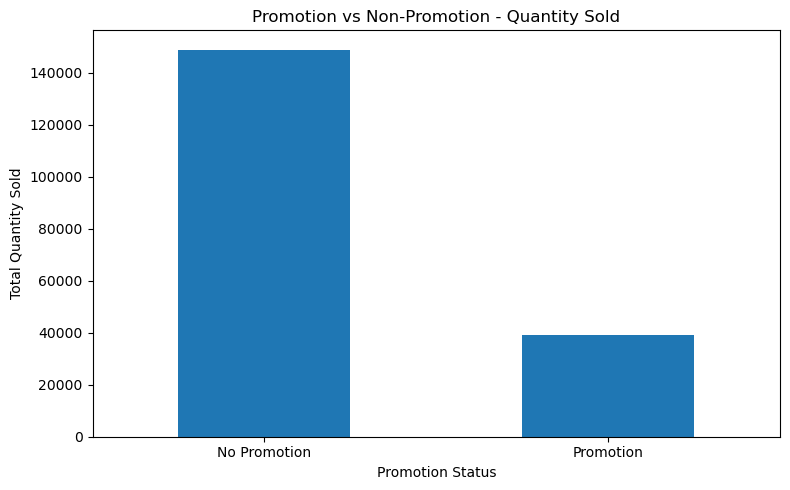

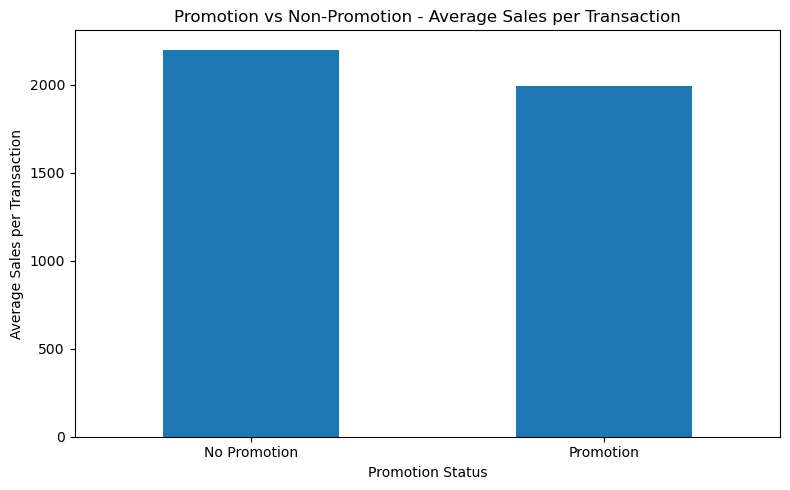

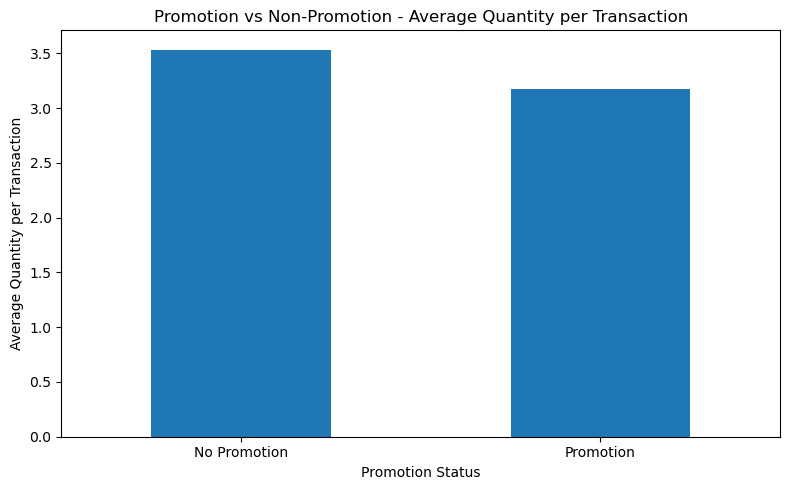


========== STEP 3.9 COMPLETED ==========


In [41]:
# ============================================================
# STEP 3.9 - PROMOTION VS NON-PROMOTION ANALYSIS
# ============================================================

print("\n========== STEP 3.9 - PROMOTION VS NON-PROMOTION ==========\n")

# ------------------------------------------------------------
# 1. PROMOTION STATUS
# ------------------------------------------------------------

# Make sure promotion_status is correct
cleaned_sales["promotion_status"] = cleaned_sales["promo_id"].apply(
    lambda x: "No Promotion"
    if str(x).strip().upper() == "NO_PROMO"
    else "Promotion"
)

# ------------------------------------------------------------
# 2. PROMOTION VS NON-PROMOTION SUMMARY
# ------------------------------------------------------------

promo_summary = (
    cleaned_sales
    .groupby("promotion_status")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
)

# Average sales per transaction
promo_summary["avg_sales_per_transaction"] = (
    promo_summary["total_sales"] /
    promo_summary["transactions"]
)

# Average quantity per transaction
promo_summary["avg_quantity_per_transaction"] = (
    promo_summary["total_quantity"] /
    promo_summary["transactions"]
)

print("========== PROMOTION VS NON-PROMOTION SUMMARY ==========")
display(promo_summary.round(2))


# ------------------------------------------------------------
# 3. TOTAL SALES COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

promo_summary["total_sales"].plot(
    kind="bar"
)

plt.title("Promotion vs Non-Promotion - Total Sales")
plt.xlabel("Promotion Status")
plt.ylabel("Total Sales Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. QUANTITY SOLD COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

promo_summary["total_quantity"].plot(
    kind="bar"
)

plt.title("Promotion vs Non-Promotion - Quantity Sold")
plt.xlabel("Promotion Status")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. AVERAGE SALES PER TRANSACTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

promo_summary["avg_sales_per_transaction"].plot(
    kind="bar"
)

plt.title(
    "Promotion vs Non-Promotion - "
    "Average Sales per Transaction"
)
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales per Transaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. AVERAGE QUANTITY PER TRANSACTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

promo_summary["avg_quantity_per_transaction"].plot(
    kind="bar"
)

plt.title(
    "Promotion vs Non-Promotion - "
    "Average Quantity per Transaction"
)
plt.xlabel("Promotion Status")
plt.ylabel("Average Quantity per Transaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


print("\n========== STEP 3.9 COMPLETED ==========")

=============== STEP 3.10 - MONTH-WISE SALES TREND ===============

========== MONTH-WISE SALES SUMMARY ==========


,month_period,total_quantity,total_sales,transactions,month
0,2022-01,2973,1754710.93,838,2022-01
1,2022-02,2850,1815388.49,757,2022-02
2,2022-03,3265,2018472.18,934,2022-03
3,2022-04,3446,2062692.27,946,2022-04
4,2022-05,3711,2283129.40,1011,2022-05
5,2022-06,3645,2306505.18,983,2022-06
6,2022-07,3403,2209890.33,936,2022-07
7,2022-08,3832,2439915.85,1051,2022-08
8,2022-09,3590,2207109.35,1018,2022-09
9,2022-10,3577,2253198.51,1027,2022-10


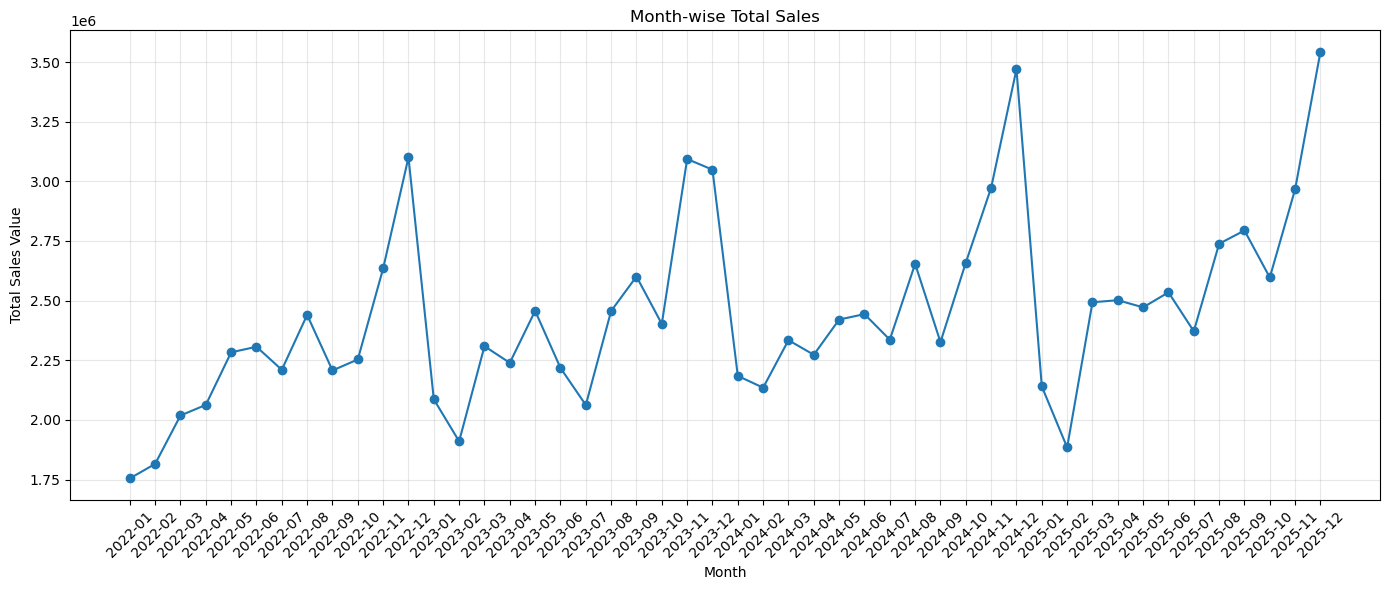

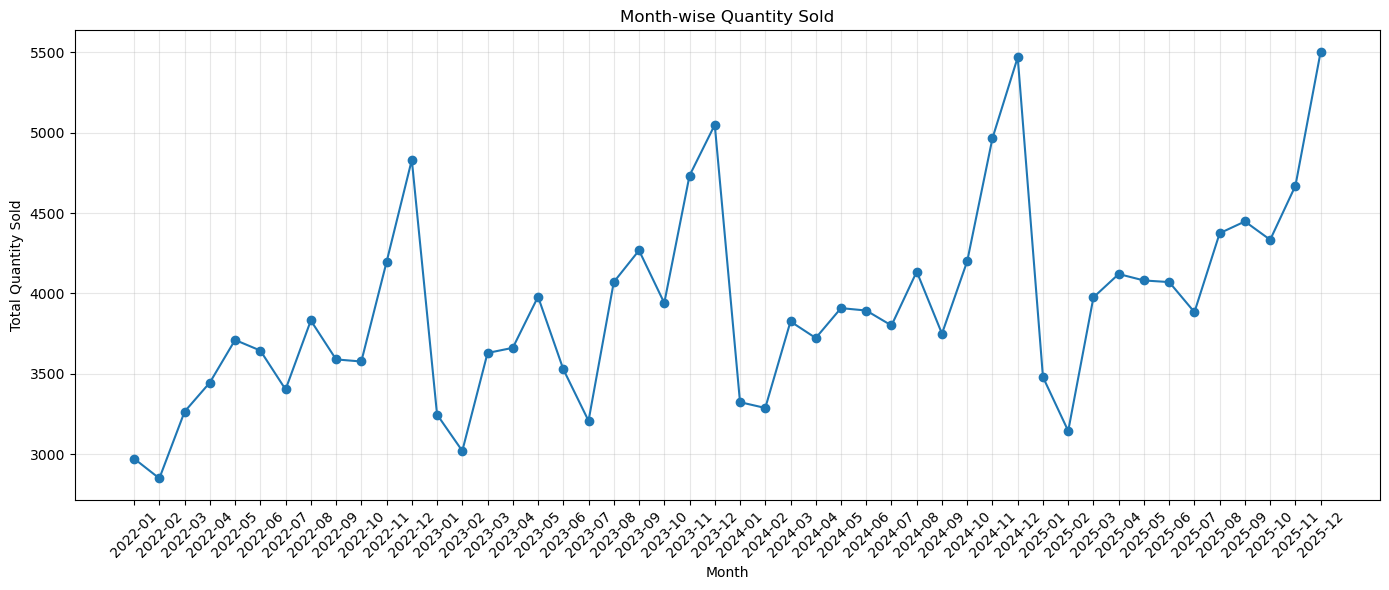


=============== STEP 3.10 COMPLETED ===============


In [42]:
# ============================================================
# STEP 3.10 - MONTH-WISE SALES TREND
# ============================================================

print("=" * 15, "STEP 3.10 - MONTH-WISE SALES TREND", "=" * 15)

# Make sure date is in datetime format
cleaned_sales['date'] = pd.to_datetime(cleaned_sales['date'])

# Create month period
cleaned_sales['month_period'] = cleaned_sales['date'].dt.to_period('M')

# Month-wise summary
monthly_sales = cleaned_sales.groupby('month_period').agg(
    total_quantity=('quantity', 'sum'),
    total_sales=('total_value', 'sum'),
    transactions=('receipt_id', 'nunique')
).reset_index()

# Convert period to string for plotting
monthly_sales['month'] = monthly_sales['month_period'].astype(str)

# Display summary
print("\n========== MONTH-WISE SALES SUMMARY ==========")
display(monthly_sales)

# ------------------------------------------------------------
# Monthly Total Sales
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['month'],
    monthly_sales['total_sales'],
    marker='o'
)

plt.title("Month-wise Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monthly Quantity Sold
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['month'],
    monthly_sales['total_quantity'],
    marker='o'
)

plt.title("Month-wise Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 15, "STEP 3.10 COMPLETED", "=" * 15)

In [43]:
import os

print("CURRENT FOLDER:")
print(os.getcwd())

print("\nFILES/FOLDERS:")
for item in os.listdir():
    print(item)

CURRENT FOLDER:
C:\Users\Deepak\Desktop\FORESIGHT PROJECT\notebooks

FILES/FOLDERS:
.ipynb_checkpoints
01_data_quality_eda.ipynb
02_baseline_forecast.ipynb
03_model_risk.ipynb


In [44]:
import os

project_path = os.path.abspath("..")

print("Searching in:")
print(project_path)

print("\nSearching for CSV files...\n")

for root, dirs, files in os.walk(project_path):
    for file in files:
        if file.lower() in ["cleaned_sales.csv", "sku_master.csv"]:
            print(os.path.join(root, file))

Searching in:
C:\Users\Deepak\Desktop\FORESIGHT PROJECT

Searching for CSV files...

C:\Users\Deepak\Desktop\FORESIGHT PROJECT\data\processed\cleaned_sales.csv
C:\Users\Deepak\Desktop\FORESIGHT PROJECT\data\raw\sku_master.csv


=============== STEP 3.11 - CATEGORY-WISE SALES ANALYSIS ===============

Cleaned Sales Shape: (99863, 11)
SKU Master Shape: (5000, 7)

Category missing values: 0

========== CATEGORY-WISE SALES SUMMARY ==========


,total_quantity,total_sales,transactions,unique_skus
category,,,,
Electronics & Accessories,13907,25260392.72,7003,394
Apparel & Footwear,12134,20230516.27,6135,410
Home & Kitchen,14392,17517514.01,7246,390
Personal Care,27235,17487969.97,13008,409
Health & Wellness,12417,9351744.75,6282,396
Frozen Foods,15564,8619056.08,7724,422
Home Care,15675,4515873.70,7903,425
Grocery,15192,3803121.18,7522,395
Dairy & Bakery,17156,3747522.83,8555,428


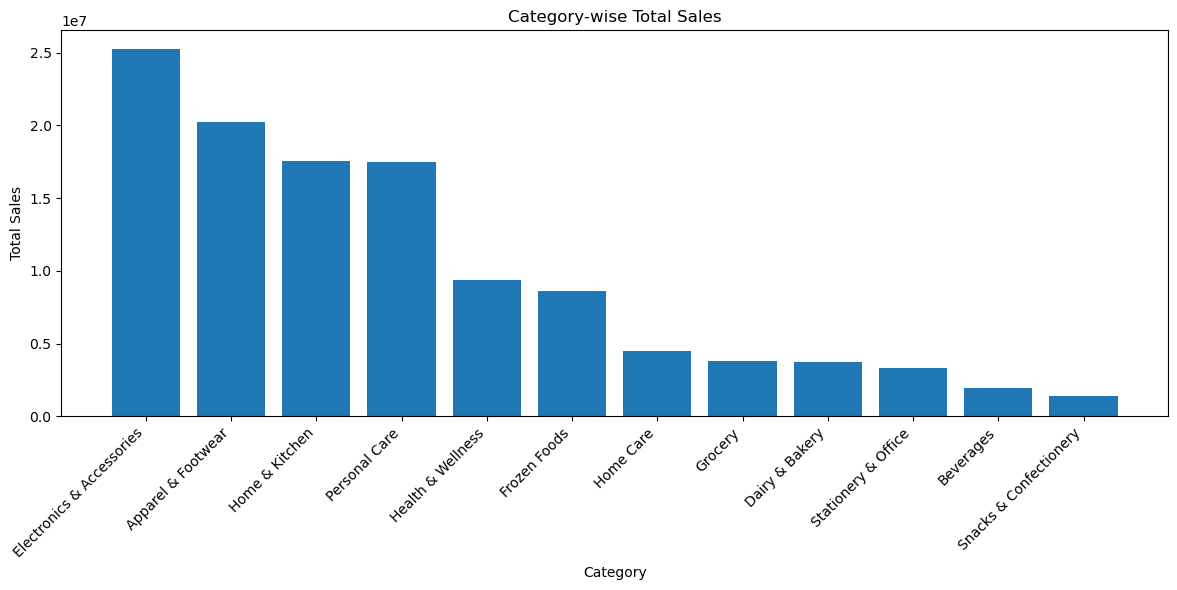

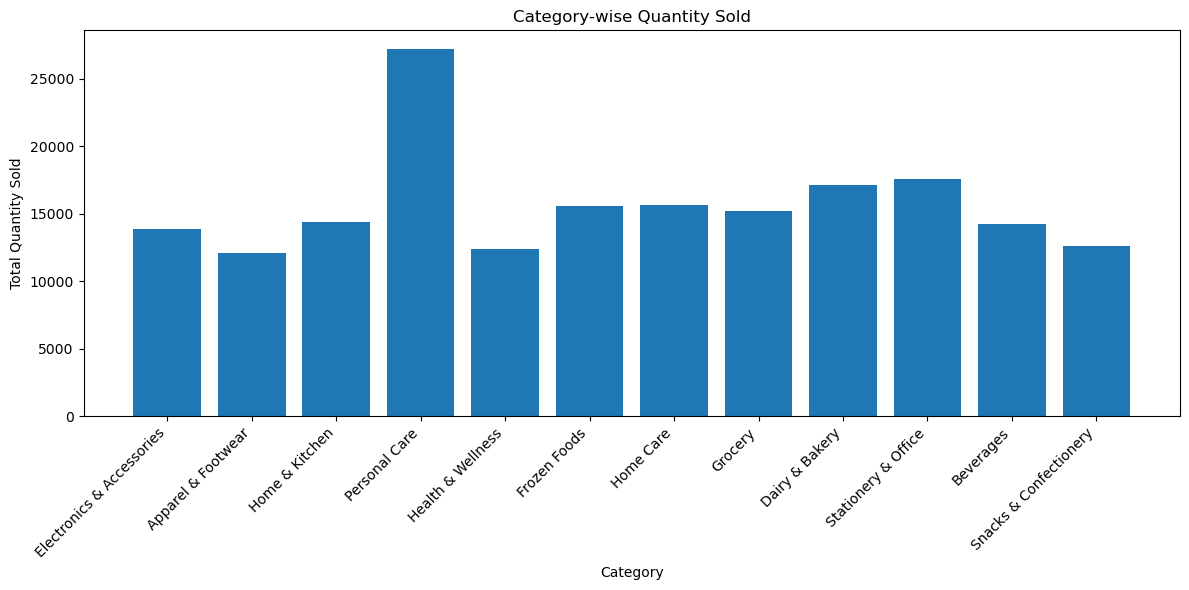


========== STEP 3.11 COMPLETED ==========


In [45]:
# ============================================================
# STEP 3.11 - CATEGORY-WISE SALES ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

print("=" * 15, "STEP 3.11 - CATEGORY-WISE SALES ANALYSIS", "=" * 15)

# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------
sales_path = os.path.join("..", "data", "processed", "cleaned_sales.csv")
sku_path = os.path.join("..", "data", "raw", "sku_master.csv")

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
cleaned_sales = pd.read_csv(sales_path)
sku_master = pd.read_csv(sku_path)

print("\nCleaned Sales Shape:", cleaned_sales.shape)
print("SKU Master Shape:", sku_master.shape)

# ------------------------------------------------------------
# 3. Add category from SKU Master
# ------------------------------------------------------------
sku_category = (
    sku_master[["sku_id", "category"]]
    .drop_duplicates()
)

cleaned_sales = cleaned_sales.merge(
    sku_category,
    on="sku_id",
    how="left"
)

print("\nCategory missing values:",
      cleaned_sales["category"].isna().sum())

# ------------------------------------------------------------
# 4. Category-wise summary
# ------------------------------------------------------------
category_summary = (
    cleaned_sales
    .groupby("category")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
    .sort_values("total_sales", ascending=False)
)

print("\n========== CATEGORY-WISE SALES SUMMARY ==========")
display(category_summary)

# ------------------------------------------------------------
# 5. Category-wise Total Sales
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    category_summary.index,
    category_summary["total_sales"]
)

plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Category-wise Quantity Sold
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.bar(
    category_summary.index,
    category_summary["total_quantity"]
)

plt.title("Category-wise Quantity Sold")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n========== STEP 3.11 COMPLETED ==========")

=============== STEP 3.12 - TOP SELLING SKU ANALYSIS ===============
Cleaned Sales Shape: (99863, 12)
SKU Master Shape: (5000, 7)

SKU Master Columns:
['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price', 'cost_price', 'brand']

Merged Shape: (99863, 15)

Merged Columns:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id', 'category', 'sku_name', 'category_master', 'subcategory']

Missing Category: 0
Missing SKU Name: 0

TOP 20 SKUs BY QUANTITY SOLD


,sku_id,sku_name,category,total_quantity,total_sales,transactions
4318,SKU04321,EliteHome Hair Care Pack of 6,Personal Care,12156,11685562.80,6170
4593,SKU04596,ValueChoice Eggs Pack of 6,Dairy & Bakery,2821,946586.55,1506
3724,SKU03727,QuickBite Mobile Accessories 2kg,Electronics & Accessories,1810,3006283.30,957
4151,SKU04154,TrueTaste Spices & Seasoning Medium,Grocery,1347,473834.19,693
952,SKU00953,CityFresh Writing Instruments 250ml,Stationery & Office,1173,321390.27,615
993,SKU00994,NovaFresh Home Decor 2L,Home & Kitchen,1004,604538.52,521
3289,SKU03292,SoftTouch Pulses & Lentils Family Pack,Grocery,997,163537.91,534
2139,SKU02141,PureLife Bath & Body Family Pack,Personal Care,988,466217.44,521
189,SKU00190,ZestyCo Writing Instruments 1L,Stationery & Office,948,137858.16,514
1773,SKU01775,CityFresh Hair Care 2L,Personal Care,790,161278.50,417



TOP 20 SKUs BY SALES VALUE


,sku_id,sku_name,category,total_quantity,total_sales,transactions
4318,SKU04321,EliteHome Hair Care Pack of 6,Personal Care,12156,11685562.80,6170
3724,SKU03727,QuickBite Mobile Accessories 2kg,Electronics & Accessories,1810,3006283.30,957
4326,SKU04329,SoftTouch Cookware 2kg,Home & Kitchen,472,1157377.04,239
4593,SKU04596,ValueChoice Eggs Pack of 6,Dairy & Bakery,2821,946586.55,1506
1370,SKU01371,PureLife Cookware 1L,Home & Kitchen,726,927544.86,379
4548,SKU04551,DailyBest Cookware Small,Home & Kitchen,320,799433.60,161
3051,SKU03053,PremiumSelect Kids Wear Family Pack,Apparel & Footwear,193,788736.96,102
1188,SKU01189,PureLife Footwear 500g,Apparel & Footwear,316,726736.80,171
4154,SKU04157,PremiumSelect Small Appliances 1L,Electronics & Accessories,271,725832.85,145
4568,SKU04571,EliteHome Ready Meals 250g,Frozen Foods,731,634888.12,397


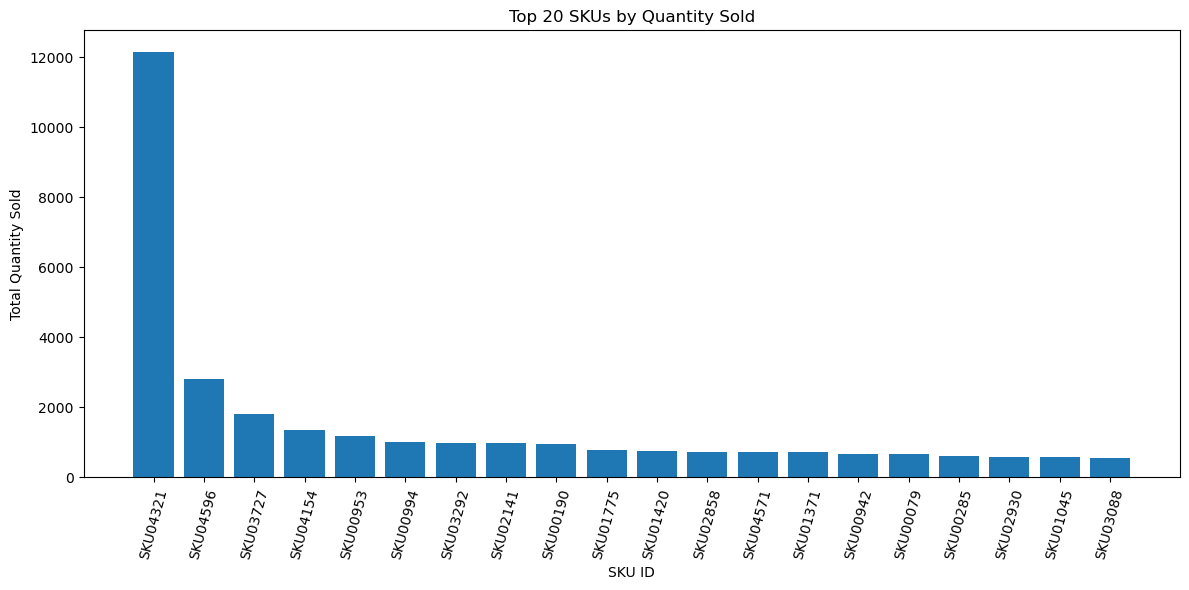

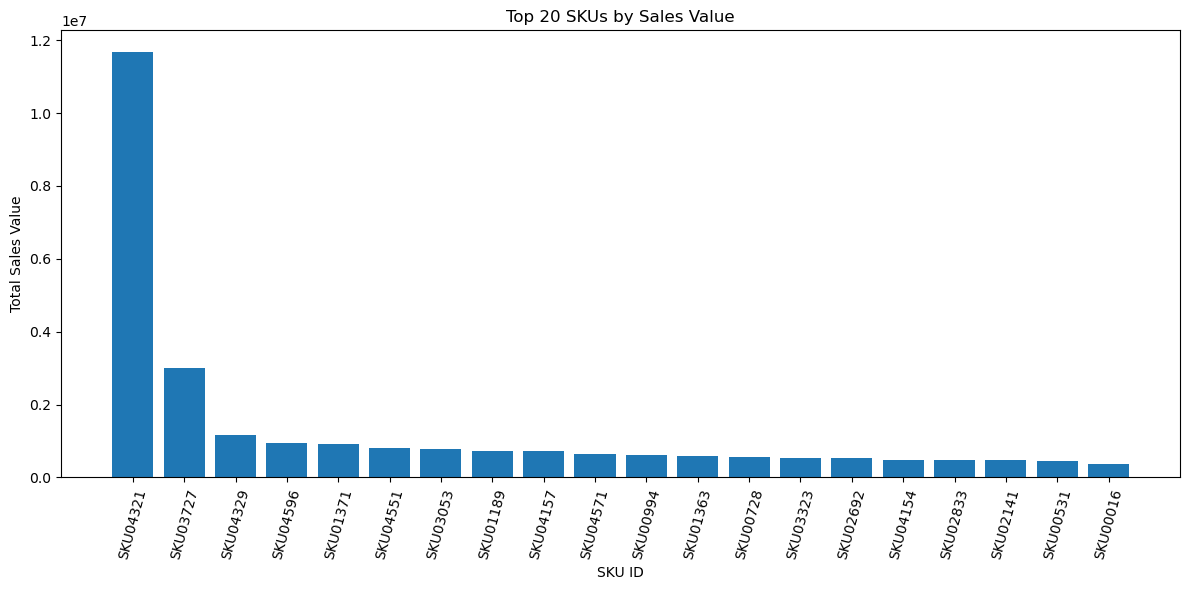


STEP 3.12 COMPLETED


In [47]:
# ============================================================
# STEP 3.12 - TOP SELLING SKU ANALYSIS
# ============================================================

print("=" * 15, "STEP 3.12 - TOP SELLING SKU ANALYSIS", "=" * 15)

# ------------------------------------------------------------
# 1. Load SKU Master
# ------------------------------------------------------------

sku_master_path = r"..\data\raw\sku_master.csv"

sku_master = pd.read_csv(sku_master_path)

print("Cleaned Sales Shape:", cleaned_sales.shape)
print("SKU Master Shape:", sku_master.shape)

print("\nSKU Master Columns:")
print(sku_master.columns.tolist())


# ------------------------------------------------------------
# 2. Keep required SKU Master columns
# ------------------------------------------------------------

sku_info = sku_master[
    ['sku_id', 'sku_name', 'category', 'subcategory']
].copy()


# ------------------------------------------------------------
# 3. Merge with cleaned sales
# ------------------------------------------------------------

sku_sales = cleaned_sales.merge(
    sku_info,
    on='sku_id',
    how='left',
    suffixes=('', '_master')
)

# If category already existed in cleaned_sales,
# use the master category column
if 'category_master' in sku_sales.columns:
    sku_sales['category'] = sku_sales['category_master']

if 'sku_name_master' in sku_sales.columns:
    sku_sales['sku_name'] = sku_sales['sku_name_master']

print("\nMerged Shape:", sku_sales.shape)

print("\nMerged Columns:")
print(sku_sales.columns.tolist())

print("\nMissing Category:",
      sku_sales['category'].isna().sum())

print("Missing SKU Name:",
      sku_sales['sku_name'].isna().sum())


# ------------------------------------------------------------
# 4. TOP 20 SKUs BY QUANTITY
# ------------------------------------------------------------

top_skus_quantity = (
    sku_sales
    .groupby(
        ['sku_id', 'sku_name', 'category'],
        as_index=False
    )
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('total_value', 'sum'),
        transactions=('receipt_id', 'nunique')
    )
    .sort_values(
        'total_quantity',
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 10)
print("TOP 20 SKUs BY QUANTITY SOLD")
print("=" * 10)

display(top_skus_quantity)


# ------------------------------------------------------------
# 5. TOP 20 SKUs BY SALES VALUE
# ------------------------------------------------------------

top_skus_sales = (
    sku_sales
    .groupby(
        ['sku_id', 'sku_name', 'category'],
        as_index=False
    )
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('total_value', 'sum'),
        transactions=('receipt_id', 'nunique')
    )
    .sort_values(
        'total_sales',
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 10)
print("TOP 20 SKUs BY SALES VALUE")
print("=" * 10)

display(top_skus_sales)


# ------------------------------------------------------------
# 6. TOP SKUs - QUANTITY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    top_skus_quantity['sku_id'].astype(str),
    top_skus_quantity['total_quantity']
)

plt.title("Top 20 SKUs by Quantity Sold")
plt.xlabel("SKU ID")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. TOP SKUs - SALES GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    top_skus_sales['sku_id'].astype(str),
    top_skus_sales['total_sales']
)

plt.title("Top 20 SKUs by Sales Value")
plt.xlabel("SKU ID")
plt.ylabel("Total Sales Value")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()


print("\n" + "=" * 15)
print("STEP 3.12 COMPLETED")
print("=" * 15)

=============== STEP 3.13 - SLOW-MOVING / DEAD STOCK ANALYSIS ===============

SKU MOVEMENT SUMMARY


,movement_status,unique_skus,total_quantity,total_sales
0,Dead Stock,2,0.0,0.00
1,Fast Moving,230,67918.0,43584301.51
2,Moderate,431,30032.0,17123589.21
3,Slow Moving,3668,84970.0,53349493.30
4,Very Slow,669,5114.0,3155300.32



TOP 20 SLOW-MOVING SKUs


,sku_id,sku_name,category,total_quantity,total_sales,transactions,movement_status
300,SKU00301,HealthFirst Notebooks Family Pack,Stationery & Office,1.0,316.89,1.0,Very Slow
990,SKU00991,PurePlus Cookware 100g,Home & Kitchen,1.0,226.46,1.0,Very Slow
1157,SKU01158,CleanWave Chips & Crisps Large,Snacks & Confectionery,1.0,90.44,1.0,Very Slow
2356,SKU02357,ZestyCo Laundry 1kg,Home Care,1.0,170.99,1.0,Very Slow
2500,SKU02501,SoftTouch Storage & Containers 2L,Home & Kitchen,1.0,490.38,1.0,Very Slow
2910,SKU02911,FreshFarm Biscuits & Cookies 250ml,Snacks & Confectionery,1.0,133.23,1.0,Very Slow
4105,SKU04106,EverydayPlus Cheese 250ml,Dairy & Bakery,1.0,92.02,1.0,Very Slow
782,SKU00783,UrbanBite Butter & Ghee Pack of 12,Dairy & Bakery,2.0,393.58,1.0,Very Slow
3219,SKU03220,CrispKing Energy Drinks Small,Beverages,2.0,166.22,1.0,Very Slow
3748,SKU03749,PremiumSelect Eggs 250ml,Dairy & Bakery,2.0,459.68,1.0,Very Slow



DEAD STOCK SUMMARY
Number of Dead Stock SKUs: 2
Total Dead Stock Sales: 0.0


,sku_id,sku_name,category,subcategory,total_quantity,total_sales,transactions,movement_status
1610,SKU01611,CrispKing Skin Care Pack of 6,Personal Care,Skin Care,0.0,0.0,0.0,Dead Stock
3091,SKU03092,BasicNeeds Candy Pack of 6,Snacks & Confectionery,Candy,0.0,0.0,0.0,Dead Stock


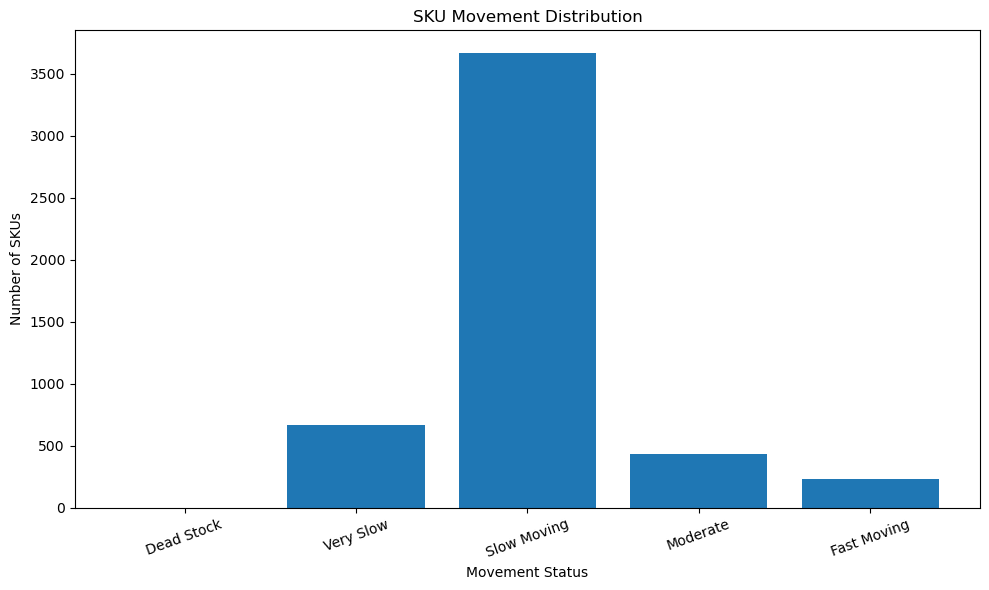

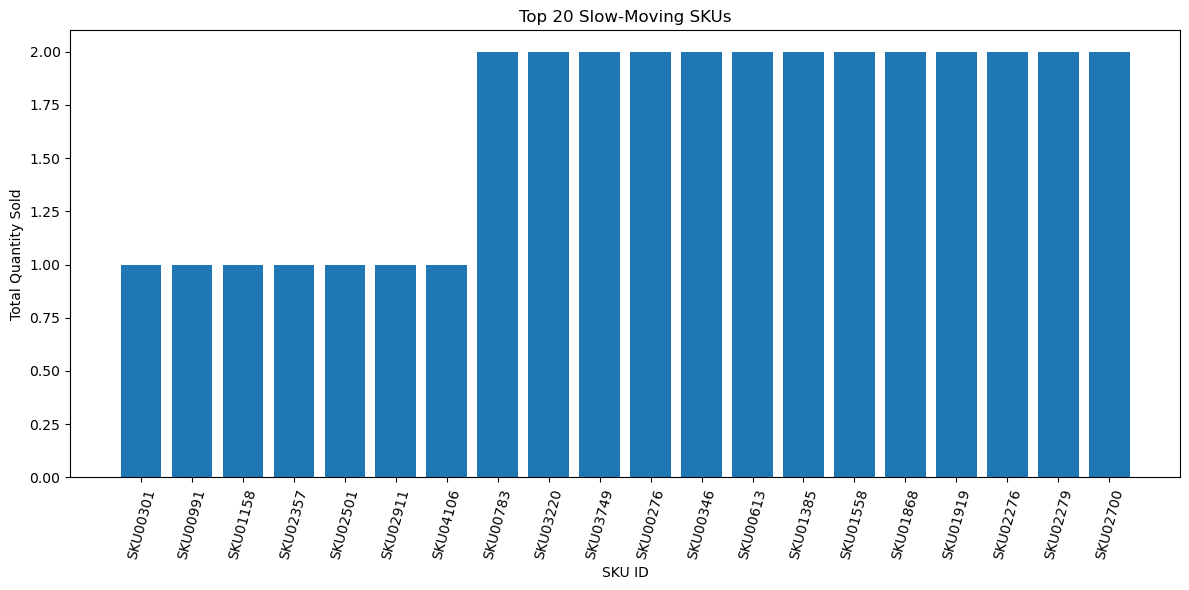


STEP 3.13 COMPLETED


In [48]:
# ============================================================
# STEP 3.13 - SLOW-MOVING / DEAD STOCK ANALYSIS
# ============================================================

print("=" * 15, "STEP 3.13 - SLOW-MOVING / DEAD STOCK ANALYSIS", "=" * 15)

# ------------------------------------------------------------
# 1. Calculate SKU-level sales
# ------------------------------------------------------------

sku_activity = (
    cleaned_sales
    .groupby('sku_id', as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('total_value', 'sum'),
        transactions=('receipt_id', 'nunique')
    )
)

# ------------------------------------------------------------
# 2. Add all 5000 SKUs from SKU Master
# ------------------------------------------------------------

sku_activity = sku_master[
    ['sku_id', 'sku_name', 'category', 'subcategory']
].merge(
    sku_activity,
    on='sku_id',
    how='left'
)

# SKUs with no recorded sales become zero
sku_activity['total_quantity'] = sku_activity['total_quantity'].fillna(0)
sku_activity['total_sales'] = sku_activity['total_sales'].fillna(0)
sku_activity['transactions'] = sku_activity['transactions'].fillna(0)

# ------------------------------------------------------------
# 3. Classify SKU movement
# ------------------------------------------------------------

def classify_sku(row):

    if row['total_quantity'] == 0:
        return 'Dead Stock'

    elif row['total_quantity'] <= 10:
        return 'Very Slow'

    elif row['total_quantity'] <= 50:
        return 'Slow Moving'

    elif row['total_quantity'] <= 100:
        return 'Moderate'

    else:
        return 'Fast Moving'


sku_activity['movement_status'] = sku_activity.apply(
    classify_sku,
    axis=1
)

# ------------------------------------------------------------
# 4. Movement summary
# ------------------------------------------------------------

movement_summary = (
    sku_activity
    .groupby('movement_status')
    .agg(
        unique_skus=('sku_id', 'count'),
        total_quantity=('total_quantity', 'sum'),
        total_sales=('total_sales', 'sum')
    )
    .reset_index()
)

print("\n" + "=" * 10)
print("SKU MOVEMENT SUMMARY")
print("=" * 10)

display(movement_summary)


# ------------------------------------------------------------
# 5. Top 20 Slow-Moving SKUs
# ------------------------------------------------------------

slow_moving_skus = (
    sku_activity[
        sku_activity['total_quantity'] > 0
    ]
    .sort_values(
        ['total_quantity', 'transactions'],
        ascending=[True, True]
    )
    .head(20)
)

print("\n" + "=" * 10)
print("TOP 20 SLOW-MOVING SKUs")
print("=" * 10)

display(slow_moving_skus[
    [
        'sku_id',
        'sku_name',
        'category',
        'total_quantity',
        'total_sales',
        'transactions',
        'movement_status'
    ]
])


# ------------------------------------------------------------
# 6. Dead Stock SKUs
# ------------------------------------------------------------

dead_stock = sku_activity[
    sku_activity['movement_status'] == 'Dead Stock'
].copy()

print("\n" + "=" * 10)
print("DEAD STOCK SUMMARY")
print("=" * 10)

print("Number of Dead Stock SKUs:", len(dead_stock))
print(
    "Total Dead Stock Sales:",
    dead_stock['total_sales'].sum()
)

display(dead_stock.head(20))


# ------------------------------------------------------------
# 7. Movement Distribution Graph
# ------------------------------------------------------------

movement_order = [
    'Dead Stock',
    'Very Slow',
    'Slow Moving',
    'Moderate',
    'Fast Moving'
]

movement_counts = (
    sku_activity['movement_status']
    .value_counts()
    .reindex(movement_order, fill_value=0)
)

plt.figure(figsize=(10, 6))

plt.bar(
    movement_counts.index,
    movement_counts.values
)

plt.title("SKU Movement Distribution")
plt.xlabel("Movement Status")
plt.ylabel("Number of SKUs")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Top 20 Slow-Moving SKU Graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    slow_moving_skus['sku_id'].astype(str),
    slow_moving_skus['total_quantity']
)

plt.title("Top 20 Slow-Moving SKUs")
plt.xlabel("SKU ID")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


print("\n" + "=" * 15)
print("STEP 3.13 COMPLETED")
print("=" * 15)

=============== STEP 3.14 - CATEGORY-WISE SLOW-MOVING SKU ANALYSIS ===============

CATEGORY-WISE SKU MOVEMENT SUMMARY


,category,movement_status,unique_skus,total_quantity,total_sales
0,Apparel & Footwear,Fast Moving,12,1921.0,3911016.48
1,Apparel & Footwear,Moderate,39,2893.0,4326724.90
2,Apparel & Footwear,Slow Moving,302,6882.0,11271920.89
3,Apparel & Footwear,Very Slow,57,438.0,720854.00
4,Beverages,Fast Moving,14,2888.0,390229.95
5,Beverages,Moderate,42,2926.0,409872.11
6,Beverages,Slow Moving,342,7940.0,1093087.64
7,Beverages,Very Slow,59,461.0,57203.96
8,Dairy & Bakery,Fast Moving,25,6897.0,1713665.19
9,Dairy & Bakery,Moderate,38,2537.0,495735.10



TOP CATEGORIES WITH SLOW-MOVING SKUs


,category,slow_moving_skus,total_quantity,total_sales
1,Beverages,401,8401.0,1150291.60
11,Stationery & Office,400,8079.0,1472751.24
4,Frozen Foods,370,8097.0,4482748.58
8,Home Care,370,7805.0,2338703.04
2,Dairy & Bakery,365,7722.0,1538122.54
10,Snacks & Confectionery,362,7528.0,851704.76
0,Apparel & Footwear,359,7320.0,11992774.89
3,Electronics & Accessories,351,7450.0,13878604.46
9,Personal Care,349,6859.0,2754071.19
6,Health & Wellness,345,6970.0,5395326.13



SLOW-MOVING SKU PERCENTAGE BY CATEGORY


,category,slow_moving_skus,total_quantity,total_sales,total_skus,slow_sku_percentage
7,Electronics & Accessories,351,7450.0,13878604.46,394,89.086294
0,Beverages,401,8401.0,1150291.60,457,87.746171
2,Frozen Foods,370,8097.0,4482748.58,422,87.677725
6,Apparel & Footwear,359,7320.0,11992774.89,410,87.560976
5,Snacks & Confectionery,362,7528.0,851704.76,414,87.439614
1,Stationery & Office,400,8079.0,1472751.24,459,87.145969
9,Health & Wellness,345,6970.0,5395326.13,396,87.121212
3,Home Care,370,7805.0,2338703.04,425,87.058824
10,Home & Kitchen,335,7028.0,8916002.45,390,85.897436
4,Dairy & Bakery,365,7722.0,1538122.54,428,85.280374


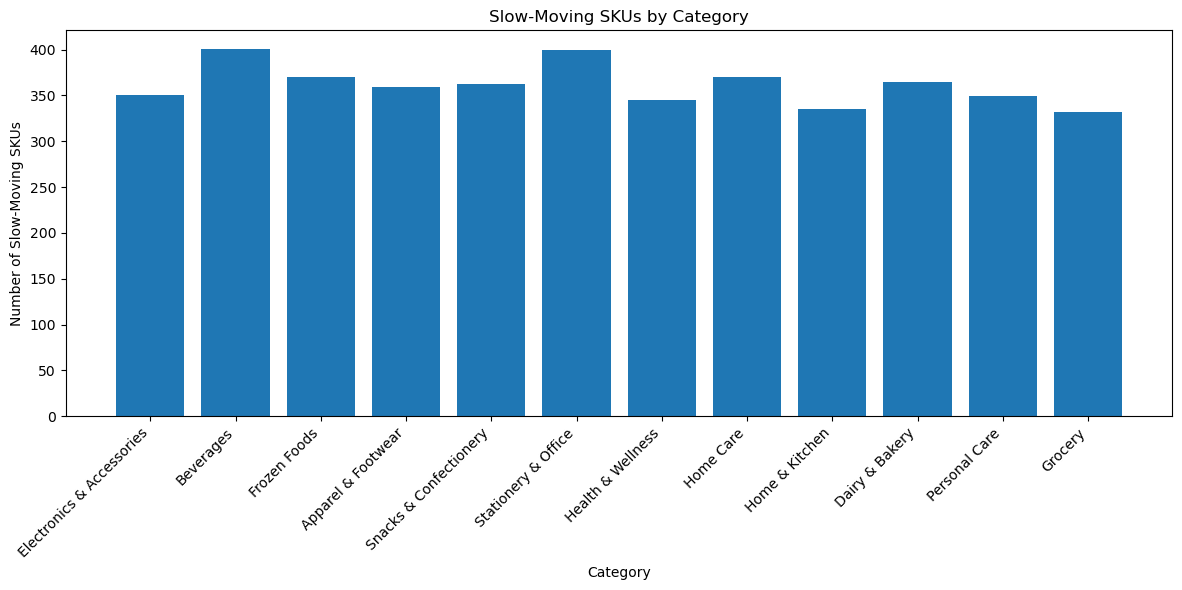

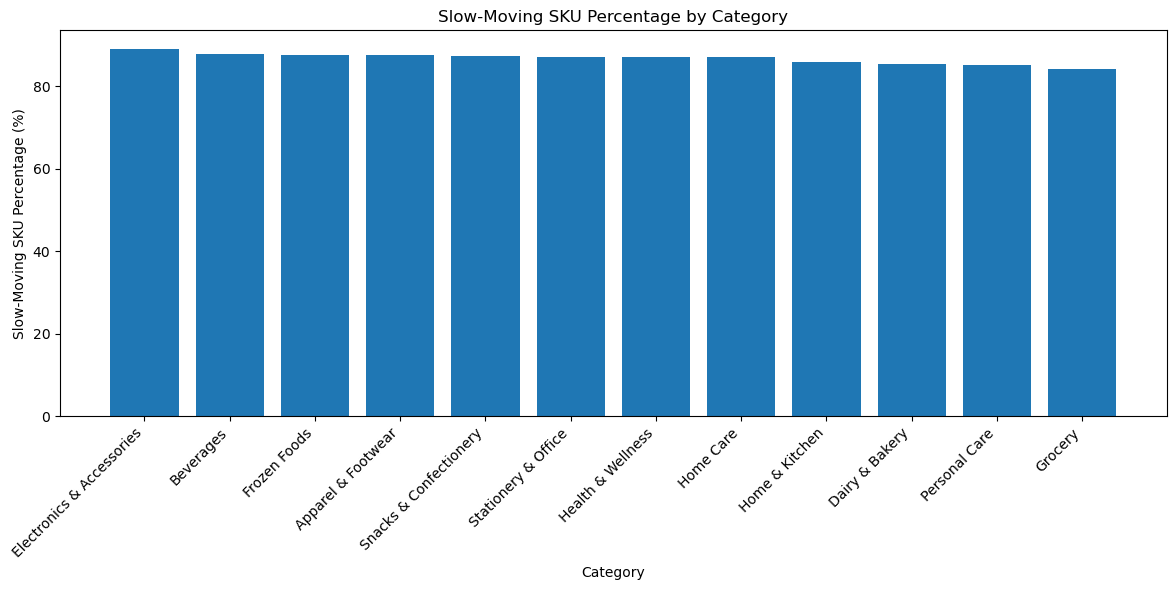


STEP 3.14 COMPLETED


In [49]:
# ============================================================
# STEP 3.14 - CATEGORY-WISE SLOW-MOVING SKU ANALYSIS
# ============================================================

print("=" * 15, "STEP 3.14 - CATEGORY-WISE SLOW-MOVING SKU ANALYSIS", "=" * 15)

# ------------------------------------------------------------
# 1. Count SKUs by category and movement status
# ------------------------------------------------------------

category_movement = (
    sku_activity
    .groupby(['category', 'movement_status'])
    .agg(
        unique_skus=('sku_id', 'count'),
        total_quantity=('total_quantity', 'sum'),
        total_sales=('total_sales', 'sum')
    )
    .reset_index()
)

print("\nCATEGORY-WISE SKU MOVEMENT SUMMARY")
print("=" * 50)

display(category_movement)


# ------------------------------------------------------------
# 2. Slow + Very Slow + Dead Stock by category
# ------------------------------------------------------------

slow_categories = sku_activity[
    sku_activity['movement_status'].isin(
        ['Dead Stock', 'Very Slow', 'Slow Moving']
    )
]

slow_category_summary = (
    slow_categories
    .groupby('category')
    .agg(
        slow_moving_skus=('sku_id', 'count'),
        total_quantity=('total_quantity', 'sum'),
        total_sales=('total_sales', 'sum')
    )
    .reset_index()
    .sort_values(
        'slow_moving_skus',
        ascending=False
    )
)

print("\n" + "=" * 10)
print("TOP CATEGORIES WITH SLOW-MOVING SKUs")
print("=" * 10)

display(slow_category_summary)


# ------------------------------------------------------------
# 3. Percentage of SKUs that are slow-moving
# ------------------------------------------------------------

category_total = (
    sku_activity
    .groupby('category')
    .agg(
        total_skus=('sku_id', 'count')
    )
    .reset_index()
)

slow_category_summary = slow_category_summary.merge(
    category_total,
    on='category',
    how='left'
)

slow_category_summary['slow_sku_percentage'] = (
    slow_category_summary['slow_moving_skus']
    / slow_category_summary['total_skus']
    * 100
)

slow_category_summary = slow_category_summary.sort_values(
    'slow_sku_percentage',
    ascending=False
)

print("\n" + "=" * 10)
print("SLOW-MOVING SKU PERCENTAGE BY CATEGORY")
print("=" * 10)

display(slow_category_summary)


# ------------------------------------------------------------
# 4. Graph - Slow-moving SKUs by category
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    slow_category_summary['category'],
    slow_category_summary['slow_moving_skus']
)

plt.title("Slow-Moving SKUs by Category")
plt.xlabel("Category")
plt.ylabel("Number of Slow-Moving SKUs")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Graph - Slow-moving percentage
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    slow_category_summary['category'],
    slow_category_summary['slow_sku_percentage']
)

plt.title("Slow-Moving SKU Percentage by Category")
plt.xlabel("Category")
plt.ylabel("Slow-Moving SKU Percentage (%)")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\n" + "=" * 15)
print("STEP 3.14 COMPLETED")
print("=" * 15)

==================== STEP 3.15 - TIME-WISE SALES TREND ANALYSIS ====================

Cleaned Sales Shape: (99863, 12)
Columns: ['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id', 'category']

Valid date rows: 99863
Date Range:
Start: 2022-01-01 00:00:00
End  : 2025-12-31 00:00:00

========== DAILY SALES SUMMARY ==========
        date  total_quantity  total_sales  transactions
0 2022-01-01             125     61969.91            30
1 2022-01-02              82     45974.94            23
2 2022-01-03             100     55909.70            26
3 2022-01-04              74     29050.21            24
4 2022-01-05              60     33405.82            17
5 2022-01-06             101     56914.20            28
6 2022-01-07              63     28843.09            16
7 2022-01-08             116     68936.97            29
8 2022-01-09             104     58131.56            30
9 2022-01-10              8

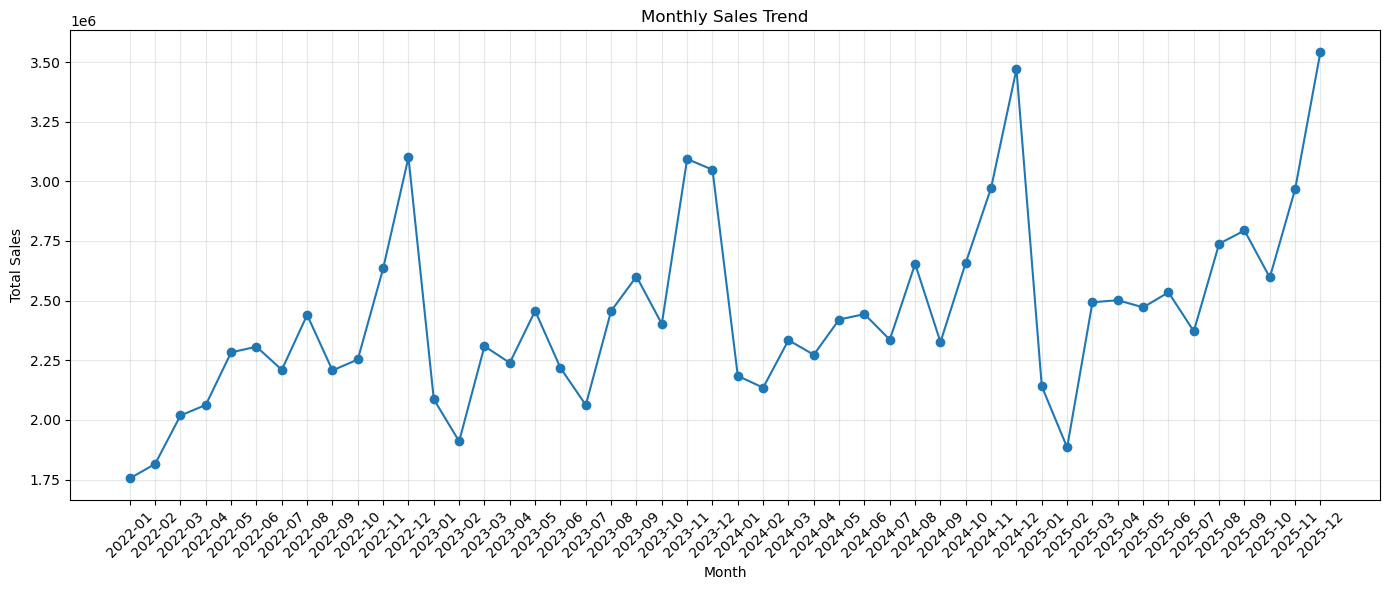

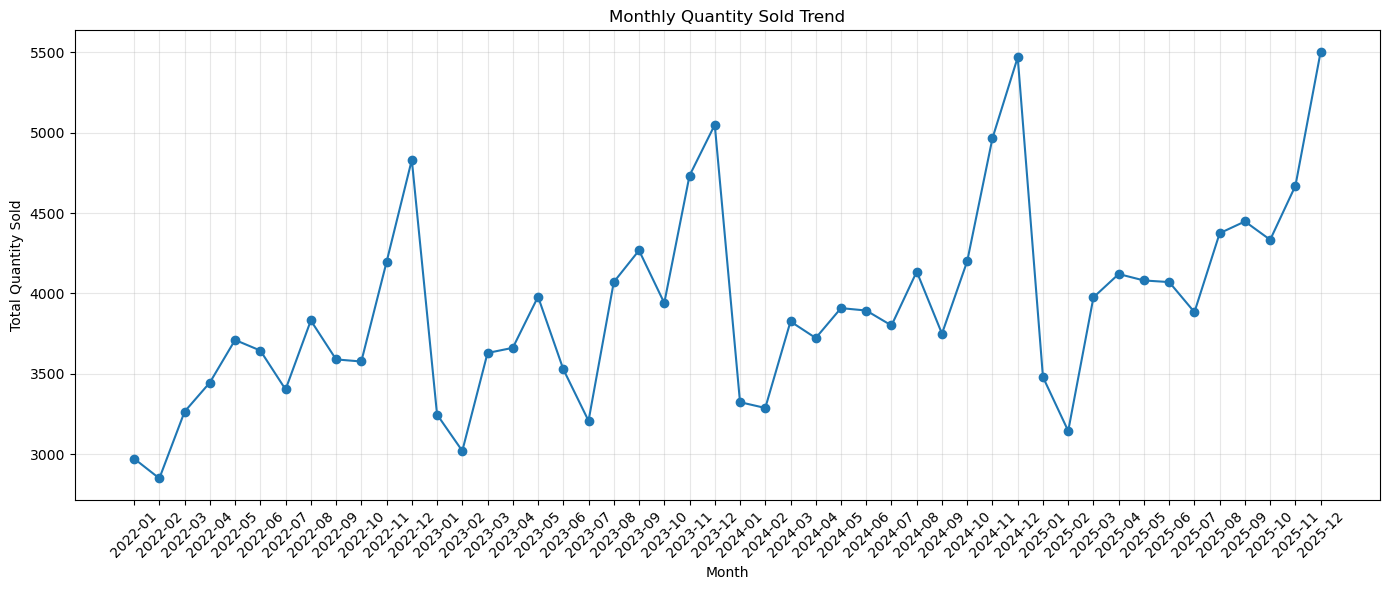


STEP 3.15 COMPLETED


In [50]:
# ============================================================
# STEP 3.15 - TIME-WISE SALES TREND ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 20, "STEP 3.15 - TIME-WISE SALES TREND ANALYSIS", "=" * 20)

# ------------------------------------------------------------
# 1. Check required columns
# ------------------------------------------------------------

print("\nCleaned Sales Shape:", cleaned_sales.shape)
print("Columns:", cleaned_sales.columns.tolist())

# ------------------------------------------------------------
# 2. Prepare date column
# ------------------------------------------------------------

cleaned_sales["date"] = pd.to_datetime(
    cleaned_sales["date"],
    errors="coerce"
)

# Remove rows where date is missing
time_sales = cleaned_sales.dropna(subset=["date"]).copy()

print("\nValid date rows:", len(time_sales))
print("Date Range:")
print("Start:", time_sales["date"].min())
print("End  :", time_sales["date"].max())

# ------------------------------------------------------------
# 3. Daily sales summary
# ------------------------------------------------------------

daily_sales = (
    time_sales
    .groupby("date")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

print("\n========== DAILY SALES SUMMARY ==========")
print(daily_sales.head(10))

# ------------------------------------------------------------
# 4. Monthly sales summary
# ------------------------------------------------------------

time_sales["month"] = time_sales["date"].dt.to_period("M").astype(str)

monthly_sales = (
    time_sales
    .groupby("month")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

print("\n========== MONTHLY SALES SUMMARY ==========")
print(monthly_sales)

# ------------------------------------------------------------
# 5. Monthly Sales Trend
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Monthly Quantity Trend
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["total_quantity"],
    marker="o"
)

plt.title("Monthly Quantity Sold Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSTEP 3.15 COMPLETED")

==================== STEP 3.16 - MONTH-WISE SEASONALITY ANALYSIS ====================

========== MONTH-WISE SEASONALITY ==========
 month_num month_name  avg_yearly_sales  avg_yearly_quantity  transactions
         1    January      2041369.3850              3256.00          3604
         2   February      1936203.2100              3076.00          3363
         3      March      2288569.0525              3674.25          4057
         4      April      2269065.8000              3738.00          4106
         5        May      2408057.2850              3920.25          4267
         6       June      2375495.0325              3784.75          4140
         7       July      2244938.9125              3574.00          3897
         8     August      2572158.6150              4103.50          4520
         9  September      2481978.8850              4014.00          4416
        10    October      2477767.7150              4013.25          4375
        11   November      2916960.5950    

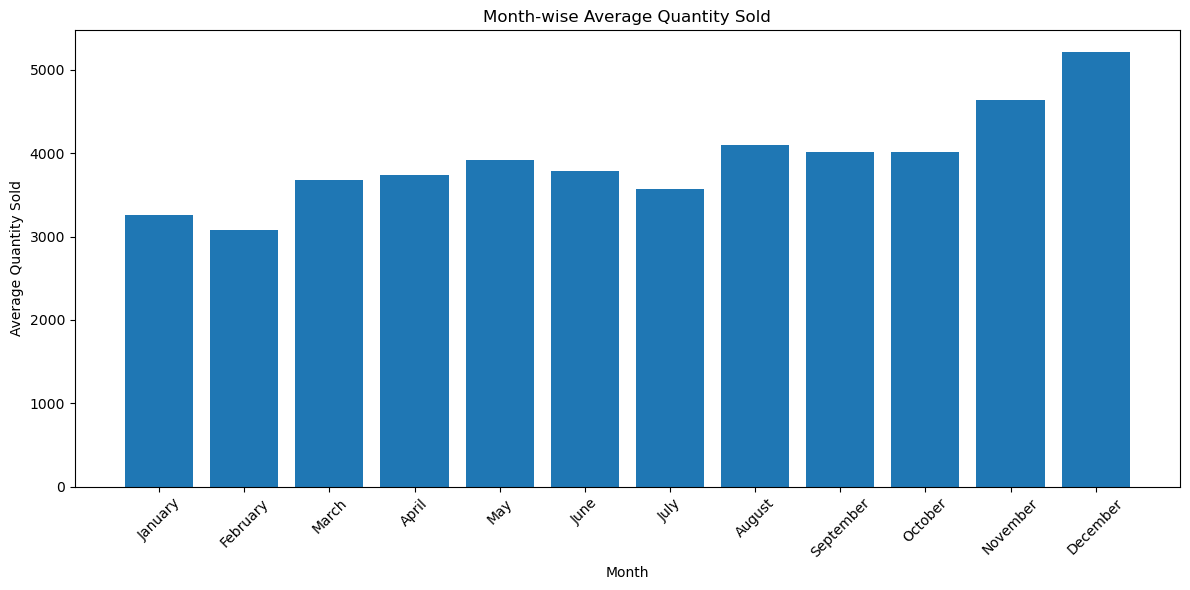

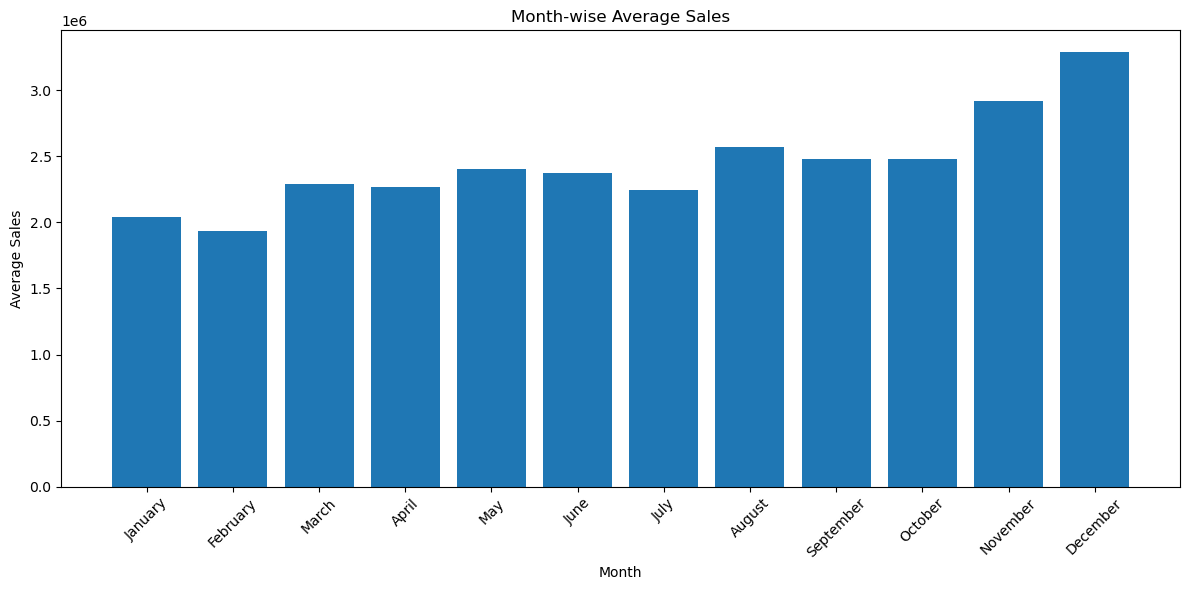


STEP 3.16 COMPLETED


In [51]:
# ============================================================
# STEP 3.16 - MONTH-WISE SEASONALITY ANALYSIS
# ============================================================

print("=" * 20, "STEP 3.16 - MONTH-WISE SEASONALITY ANALYSIS", "=" * 20)

# ------------------------------------------------------------
# 1. Create month number and month name
# ------------------------------------------------------------

time_sales["month_num"] = time_sales["date"].dt.month
time_sales["month_name"] = time_sales["date"].dt.month_name()

# ------------------------------------------------------------
# 2. Month-wise average sales and quantity
# ------------------------------------------------------------

seasonality = (
    time_sales
    .groupby(["month_num", "month_name"])
    .agg(
        avg_monthly_sales=("total_value", "sum"),
        avg_monthly_quantity=("quantity", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
    .sort_values("month_num")
)

# Since there are multiple years, calculate average per year
years_count = time_sales["date"].dt.year.nunique()

seasonality["avg_yearly_sales"] = (
    seasonality["avg_monthly_sales"] / years_count
)

seasonality["avg_yearly_quantity"] = (
    seasonality["avg_monthly_quantity"] / years_count
)

print("\n========== MONTH-WISE SEASONALITY ==========")
print(
    seasonality[
        [
            "month_num",
            "month_name",
            "avg_yearly_sales",
            "avg_yearly_quantity",
            "transactions"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 3. Highest and lowest demand months
# ------------------------------------------------------------

highest_month = seasonality.loc[
    seasonality["avg_yearly_quantity"].idxmax()
]

lowest_month = seasonality.loc[
    seasonality["avg_yearly_quantity"].idxmin()
]

print("\n========== SEASONALITY INSIGHTS ==========")

print(
    f"Highest demand month: "
    f"{highest_month['month_name']} "
    f"({highest_month['avg_yearly_quantity']:.0f} avg quantity)"
)

print(
    f"Lowest demand month: "
    f"{lowest_month['month_name']} "
    f"({lowest_month['avg_yearly_quantity']:.0f} avg quantity)"
)

# ------------------------------------------------------------
# 4. Month-wise Quantity Chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    seasonality["month_name"],
    seasonality["avg_yearly_quantity"]
)

plt.title("Month-wise Average Quantity Sold")
plt.xlabel("Month")
plt.ylabel("Average Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Month-wise Sales Chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    seasonality["month_name"],
    seasonality["avg_yearly_sales"]
)

plt.title("Month-wise Average Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSTEP 3.16 COMPLETED")

==================== STEP 3.17 - YEAR-WISE SALES & GROWTH ANALYSIS ====================

========== YEAR-WISE SALES SUMMARY ==========
 year  total_quantity  total_sales  transactions  unique_skus  sales_growth_pct  quantity_growth_pct
 2022           43319  27085965.64         12048         4503               NaN                  NaN
 2023           46339  28882722.56         12798         4562          6.633535             6.971537
 2024           48287  30207717.99         13167         4625          4.587502             4.203802
 2025           50089  31036278.15         13850         4672          2.742876             3.731853

========== YEARLY INSIGHTS ==========
Highest sales year: 2025 (₹31,036,278.15)
Lowest sales year: 2022 (₹27,085,965.64)


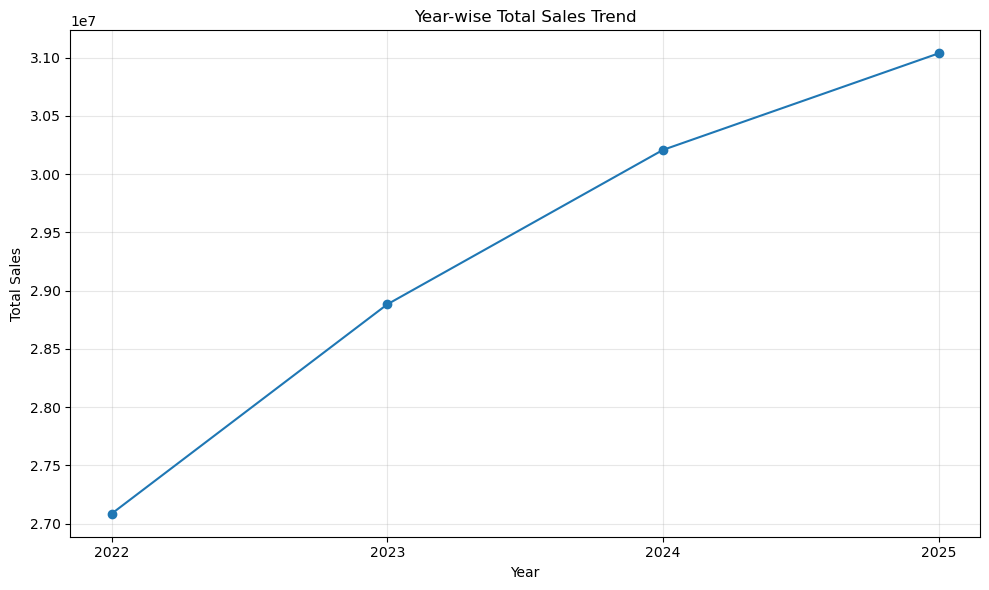

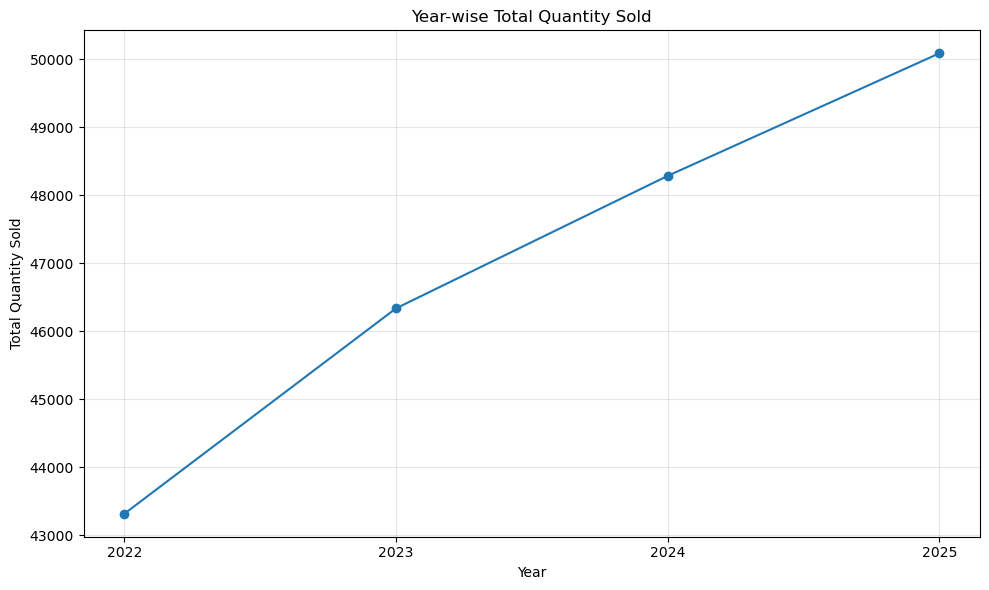


STEP 3.17 COMPLETED


In [52]:
# ============================================================
# STEP 3.17 - YEAR-WISE SALES & GROWTH ANALYSIS
# ============================================================

print("=" * 20, "STEP 3.17 - YEAR-WISE SALES & GROWTH ANALYSIS", "=" * 20)

# ------------------------------------------------------------
# 1. Create Year column
# ------------------------------------------------------------

time_sales["year"] = time_sales["date"].dt.year

# ------------------------------------------------------------
# 2. Year-wise sales summary
# ------------------------------------------------------------

yearly_sales = (
    time_sales
    .groupby("year")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Calculate year-over-year growth
# ------------------------------------------------------------

yearly_sales["sales_growth_pct"] = (
    yearly_sales["total_sales"]
    .pct_change() * 100
)

yearly_sales["quantity_growth_pct"] = (
    yearly_sales["total_quantity"]
    .pct_change() * 100
)

# ------------------------------------------------------------
# 4. Display summary
# ------------------------------------------------------------

print("\n========== YEAR-WISE SALES SUMMARY ==========")

print(
    yearly_sales[
        [
            "year",
            "total_quantity",
            "total_sales",
            "transactions",
            "unique_skus",
            "sales_growth_pct",
            "quantity_growth_pct"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. Identify highest and lowest sales year
# ------------------------------------------------------------

highest_sales_year = yearly_sales.loc[
    yearly_sales["total_sales"].idxmax()
]

lowest_sales_year = yearly_sales.loc[
    yearly_sales["total_sales"].idxmin()
]

print("\n========== YEARLY INSIGHTS ==========")

print(
    f"Highest sales year: "
    f"{int(highest_sales_year['year'])} "
    f"(₹{highest_sales_year['total_sales']:,.2f})"
)

print(
    f"Lowest sales year: "
    f"{int(lowest_sales_year['year'])} "
    f"(₹{lowest_sales_year['total_sales']:,.2f})"
)

# ------------------------------------------------------------
# 6. Sales Growth Chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales["year"],
    yearly_sales["total_sales"],
    marker="o"
)

plt.title("Year-wise Total Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales["year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Quantity Growth Chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales["year"],
    yearly_sales["total_quantity"],
    marker="o"
)

plt.title("Year-wise Total Quantity Sold")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.xticks(yearly_sales["year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSTEP 3.17 COMPLETED")

==================== STEP 3.18 - CATEGORY-WISE SALES & QUANTITY ANALYSIS ====================

========== CATEGORY-WISE SALES SUMMARY ==========
                 category  total_quantity  total_sales  transactions  unique_skus  sales_contribution_pct  quantity_contribution_pct
Electronics & Accessories           13907  25260392.72          7003          394               21.550904                   7.396003
       Apparel & Footwear           12134  20230516.27          6135          410               17.259665                   6.453088
           Home & Kitchen           14392  17517514.01          7246          390               14.945067                   7.653935
            Personal Care           27235  17487969.97         13008          409               14.919861                  14.484083
        Health & Wellness           12417   9351744.75          6282          396                7.978441                   6.603593
             Frozen Foods           15564   8619056.08   

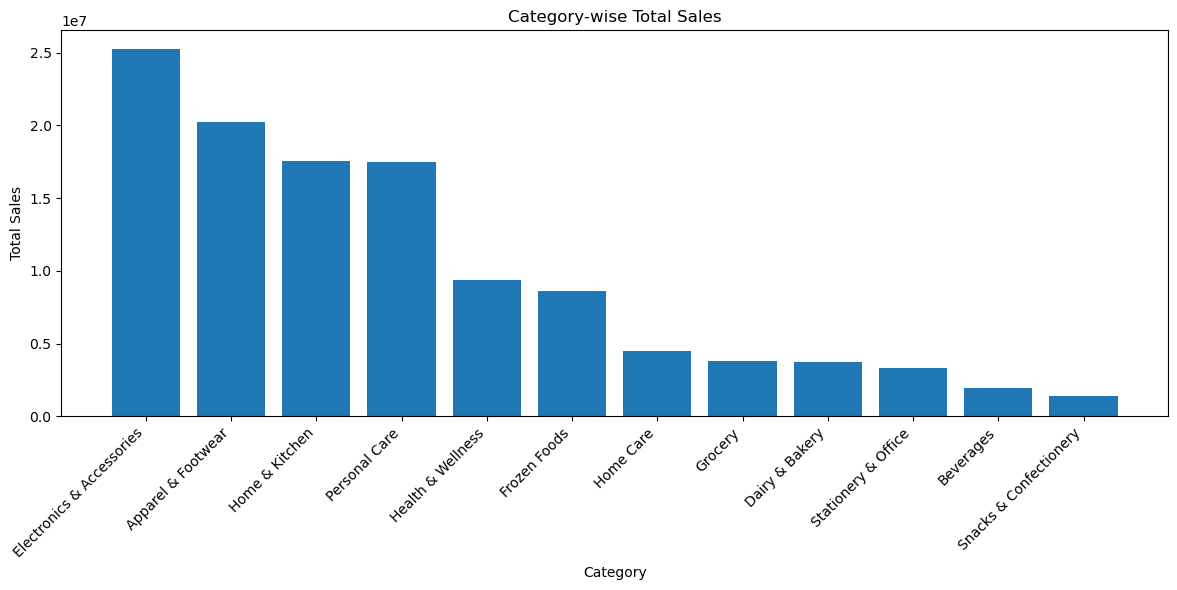

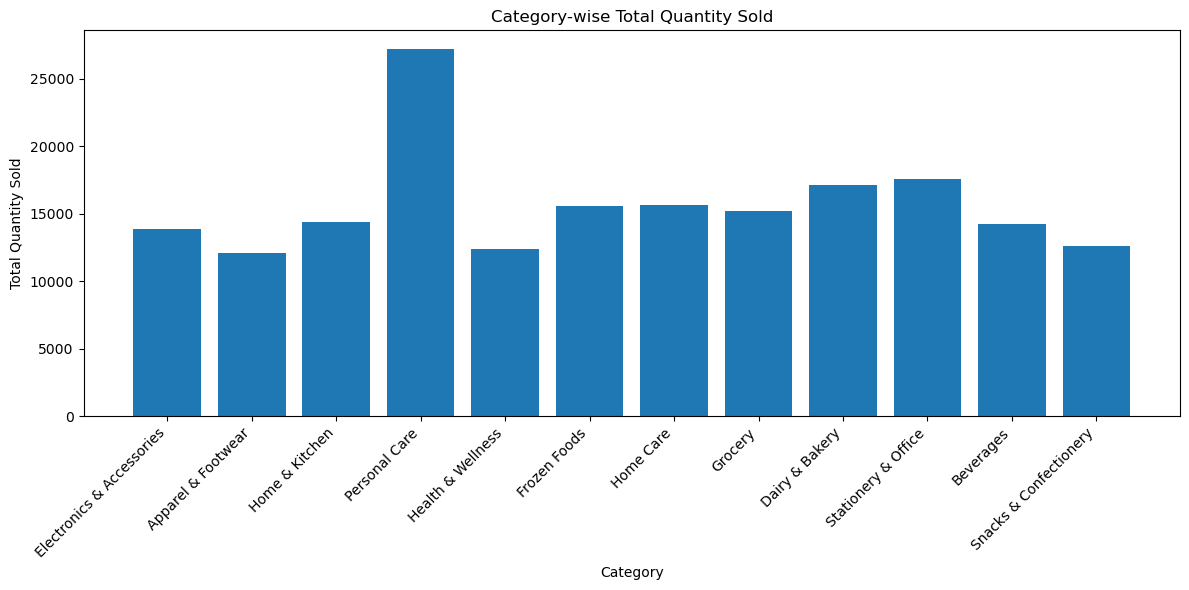


STEP 3.18 COMPLETED


In [53]:
# ============================================================
# STEP 3.18 - CATEGORY-WISE SALES & QUANTITY ANALYSIS
# ============================================================

print("=" * 20, "STEP 3.18 - CATEGORY-WISE SALES & QUANTITY ANALYSIS", "=" * 20)

# ------------------------------------------------------------
# 1. Category-wise summary
# ------------------------------------------------------------

category_sales = (
    time_sales
    .groupby("category")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Calculate contribution percentage
# ------------------------------------------------------------

category_sales["sales_contribution_pct"] = (
    category_sales["total_sales"]
    / category_sales["total_sales"].sum()
    * 100
)

category_sales["quantity_contribution_pct"] = (
    category_sales["total_quantity"]
    / category_sales["total_quantity"].sum()
    * 100
)

# ------------------------------------------------------------
# 3. Sort by sales
# ------------------------------------------------------------

category_sales = category_sales.sort_values(
    "total_sales",
    ascending=False
)

# ------------------------------------------------------------
# 4. Display summary
# ------------------------------------------------------------

print("\n========== CATEGORY-WISE SALES SUMMARY ==========")

print(
    category_sales[
        [
            "category",
            "total_quantity",
            "total_sales",
            "transactions",
            "unique_skus",
            "sales_contribution_pct",
            "quantity_contribution_pct"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. Highest / lowest categories
# ------------------------------------------------------------

highest_sales_category = category_sales.iloc[0]

lowest_sales_category = category_sales.iloc[-1]

print("\n========== CATEGORY INSIGHTS ==========")

print(
    f"Highest sales category: "
    f"{highest_sales_category['category']} "
    f"(₹{highest_sales_category['total_sales']:,.2f})"
)

print(
    f"Lowest sales category: "
    f"{lowest_sales_category['category']} "
    f"(₹{lowest_sales_category['total_sales']:,.2f})"
)

# ------------------------------------------------------------
# 6. Sales contribution chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    category_sales["category"],
    category_sales["total_sales"]
)

plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Quantity contribution chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    category_sales["category"],
    category_sales["total_quantity"]
)

plt.title("Category-wise Total Quantity Sold")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

print("\nSTEP 3.18 COMPLETED")

==================== STEP 3.19 - TOP SKU SALES & QUANTITY ANALYSIS ====================

========== TOP 20 SKUs BY SALES ==========
  sku_id                  category  total_quantity  total_sales  transactions  sales_contribution_pct
SKU04321             Personal Care           12156  11685562.80          6170                9.969538
SKU03727 Electronics & Accessories            1810   3006283.30           957                2.564811
SKU04329            Home & Kitchen             472   1157377.04           239                0.987416
SKU04596            Dairy & Bakery            2821    946586.55          1506                0.807580
SKU01371            Home & Kitchen             726    927544.86           379                0.791335
SKU04551            Home & Kitchen             320    799433.60           161                0.682037
SKU03053        Apparel & Footwear             193    788736.96           102                0.672911
SKU01189        Apparel & Footwear             316  

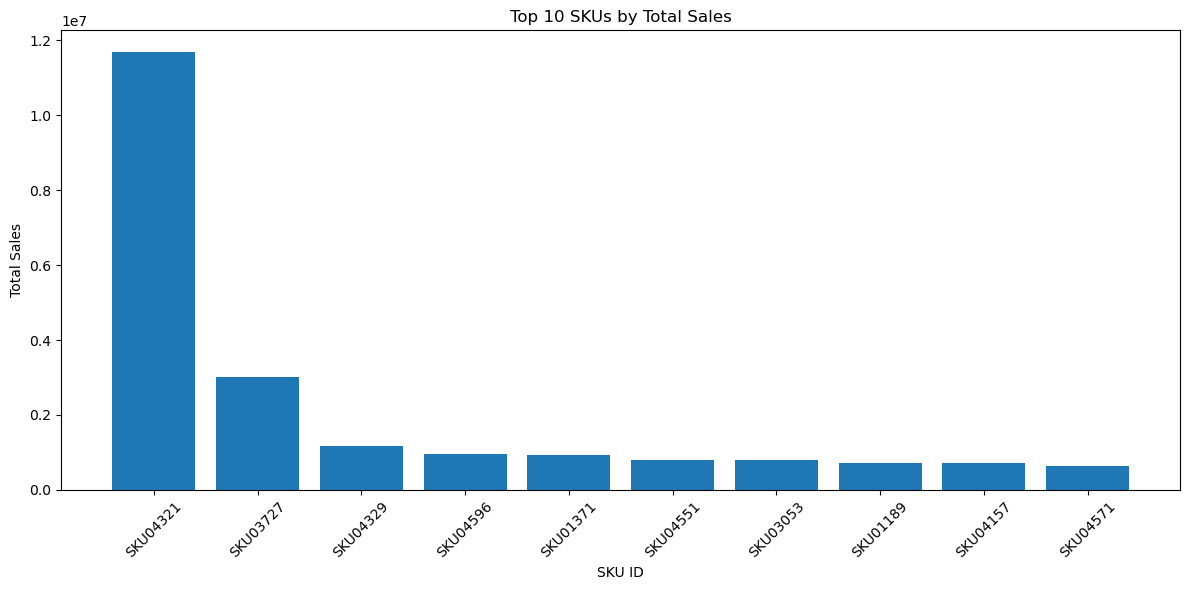

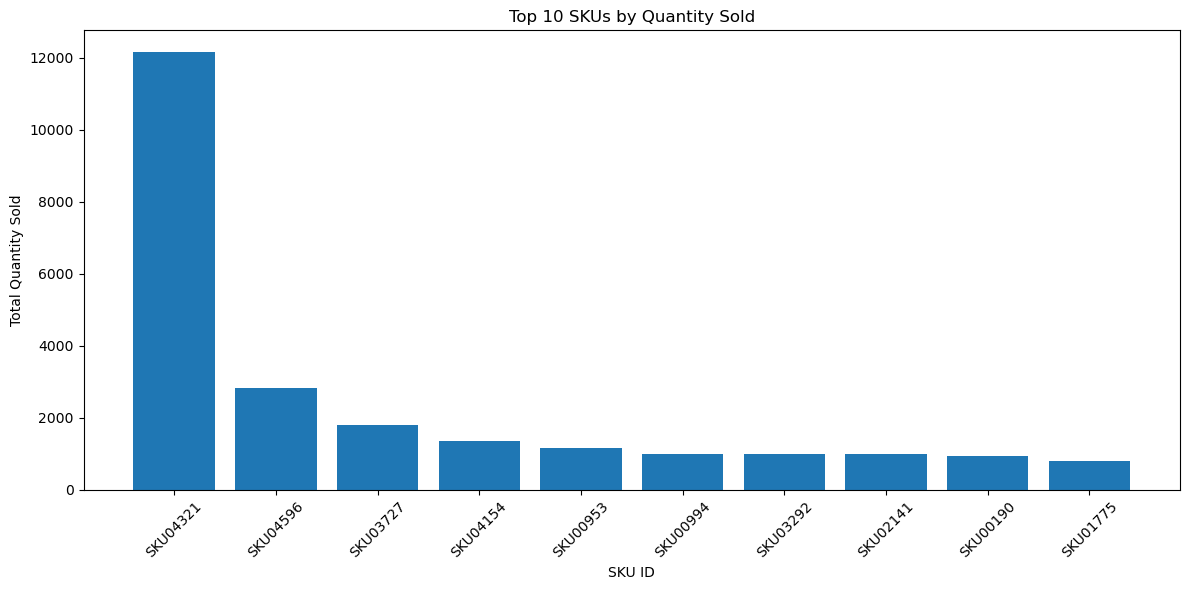


STEP 3.19 COMPLETED


In [54]:
# ============================================================
# STEP 3.19 - TOP SKU SALES & QUANTITY ANALYSIS
# ============================================================

print("=" * 20, "STEP 3.19 - TOP SKU SALES & QUANTITY ANALYSIS", "=" * 20)

# ------------------------------------------------------------
# 1. SKU-wise summary
# ------------------------------------------------------------

sku_summary = (
    time_sales
    .groupby("sku_id")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        category=("category", "first")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Sales contribution percentage
# ------------------------------------------------------------

sku_summary["sales_contribution_pct"] = (
    sku_summary["total_sales"]
    / sku_summary["total_sales"].sum()
    * 100
)

# ------------------------------------------------------------
# 3. TOP 20 SKUs BY SALES
# ------------------------------------------------------------

top_skus_sales = (
    sku_summary
    .sort_values("total_sales", ascending=False)
    .head(20)
)

print("\n========== TOP 20 SKUs BY SALES ==========")

print(
    top_skus_sales[
        [
            "sku_id",
            "category",
            "total_quantity",
            "total_sales",
            "transactions",
            "sales_contribution_pct"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 4. TOP 20 SKUs BY QUANTITY
# ------------------------------------------------------------

top_skus_quantity = (
    sku_summary
    .sort_values("total_quantity", ascending=False)
    .head(20)
)

print("\n========== TOP 20 SKUs BY QUANTITY ==========")

print(
    top_skus_quantity[
        [
            "sku_id",
            "category",
            "total_quantity",
            "total_sales",
            "transactions"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. TOP 10 SALES CONTRIBUTION
# ------------------------------------------------------------

top10_sales_contribution = (
    top_skus_sales.head(10)["sales_contribution_pct"].sum()
)

print("\n========== SKU INSIGHTS ==========")

print(
    f"Top 10 SKUs contribute "
    f"{top10_sales_contribution:.2f}% of total sales."
)

print(
    f"Highest-selling SKU: "
    f"{top_skus_sales.iloc[0]['sku_id']}"
)

print(
    f"Highest-selling SKU revenue: "
    f"₹{top_skus_sales.iloc[0]['total_sales']:,.2f}"
)

print(
    f"Highest-quantity SKU: "
    f"{top_skus_quantity.iloc[0]['sku_id']}"
)

print(
    f"Highest-quantity sold: "
    f"{top_skus_quantity.iloc[0]['total_quantity']:,.0f}"
)

# ------------------------------------------------------------
# 6. TOP 10 SKUs SALES CHART
# ------------------------------------------------------------

top10 = top_skus_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["sku_id"].astype(str),
    top10["total_sales"]
)

plt.title("Top 10 SKUs by Total Sales")
plt.xlabel("SKU ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. TOP 10 SKUs QUANTITY CHART
# ------------------------------------------------------------

top10_qty = top_skus_quantity.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_qty["sku_id"].astype(str),
    top10_qty["total_quantity"]
)

plt.title("Top 10 SKUs by Quantity Sold")
plt.xlabel("SKU ID")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nSTEP 3.19 COMPLETED")

In [55]:
# ============================================================
# STEP 3.20 - PROMOTION IMPACT ANALYSIS
# ============================================================

print("=" * 70)
print("STEP 3.20 - PROMOTION IMPACT ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create promotion status from promo_id
# ------------------------------------------------------------

cleaned_sales["promo_status"] = (
    cleaned_sales["promo_id"].notna()
)

# If promo_id contains blank strings, treat them as non-promotion
cleaned_sales["promo_status"] = (
    cleaned_sales["promo_id"]
    .astype(str)
    .str.strip()
    .replace(["", "nan", "None"], pd.NA)
    .notna()
)

print("\n========== PROMOTION STATUS ==========")
print(cleaned_sales["promo_status"].value_counts())


# ------------------------------------------------------------
# 2. Promotion vs Non-Promotion Summary
# ------------------------------------------------------------

promo_summary = (
    cleaned_sales
    .groupby("promo_status")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

# Average transaction value
promo_summary["avg_transaction_value"] = (
    promo_summary["total_sales"] /
    promo_summary["transactions"]
)

print("\n========== PROMOTION VS NON-PROMOTION ==========")
print(promo_summary)


# ------------------------------------------------------------
# 3. Promotion Impact
# ------------------------------------------------------------

if True in promo_summary["promo_status"].values and \
   False in promo_summary["promo_status"].values:

    promo_row = promo_summary[
        promo_summary["promo_status"] == True
    ].iloc[0]

    non_promo_row = promo_summary[
        promo_summary["promo_status"] == False
    ].iloc[0]

    sales_diff_pct = (
        (promo_row["avg_transaction_value"]
         - non_promo_row["avg_transaction_value"])
        / non_promo_row["avg_transaction_value"]
    ) * 100

    quantity_diff_pct = (
        (promo_row["total_quantity"]
         - non_promo_row["total_quantity"])
        / non_promo_row["total_quantity"]
    ) * 100

    print("\n========== PROMOTION IMPACT ==========")

    print(
        f"Average transaction value difference: "
        f"{sales_diff_pct:.2f}%"
    )

    print(
        f"Quantity difference: "
        f"{quantity_diff_pct:.2f}%"
    )

else:

    print("\n========== PROMOTION IMPACT ==========")

    print("Both promotion and non-promotion groups")
    print("are not available for comparison.")

    print(
        "Available statuses:",
        promo_summary["promo_status"].tolist()
    )


# ------------------------------------------------------------
# 4. Promotion Performance
# ------------------------------------------------------------

promotion_records = cleaned_sales[
    cleaned_sales["promo_status"] == True
]

print("\n========== PROMOTION PERFORMANCE ==========")

if len(promotion_records) > 0:

    promotion_sales = promotion_records["total_value"].sum()
    promotion_quantity = promotion_records["quantity"].sum()
    promotion_transactions = promotion_records["receipt_id"].nunique()

    sales_per_transaction = (
        promotion_sales / promotion_transactions
    )

    quantity_per_transaction = (
        promotion_quantity / promotion_transactions
    )

    print(f"Promotion sales: ₹{promotion_sales:,.2f}")
    print(f"Promotion quantity: {promotion_quantity:,.0f}")
    print(f"Promotion transactions: {promotion_transactions:,}")
    print(
        f"Sales per transaction: "
        f"₹{sales_per_transaction:,.2f}"
    )
    print(
        f"Quantity per transaction: "
        f"{quantity_per_transaction:.2f}"
    )

else:
    print("No promotion records found.")


print("\n" + "=" * 70)
print("STEP 3.20 COMPLETED")
print("=" * 70)

STEP 3.20 - PROMOTION IMPACT ANALYSIS

========== PROMOTION STATUS ==========
promo_status
True    99863
Name: count, dtype: int64

========== PROMOTION VS NON-PROMOTION ==========
   promo_status  total_quantity   total_sales  transactions  \
0          True          188034  1.172127e+08         51863   

   avg_transaction_value  
0            2260.044431  

========== PROMOTION IMPACT ==========
Both promotion and non-promotion groups
are not available for comparison.
Available statuses: [True]

========== PROMOTION PERFORMANCE ==========
Promotion sales: ₹117,212,684.34
Promotion quantity: 188,034
Promotion transactions: 51,863
Sales per transaction: ₹2,260.04
Quantity per transaction: 3.63

STEP 3.20 COMPLETED


STEP 3.21 - STORE-WISE SALES & QUANTITY ANALYSIS

========== STORE-WISE SALES SUMMARY ==========
store_id  total_quantity  total_sales  transactions  unique_skus  avg_transaction_value
    ST21            9260   5900052.97          2506         2359            2354.370698
    ST29            9100   5712003.34          2500         2353            2284.801336
    ST07            9026   5619085.14          2467         2351            2277.699692
    ST06            8637   5472924.10          2408         2310            2272.809012
    ST30            8826   5417771.63          2440         2293            2220.398209
    ST20            8537   5334226.15          2378         2262            2243.156497
    ST22            8598   5297018.14          2393         2216            2213.547071
    ST05            6661   4241715.80          1841         1926            2304.028137
    ST18            6719   4220924.71          1856         1902            2274.205124
    ST27            681

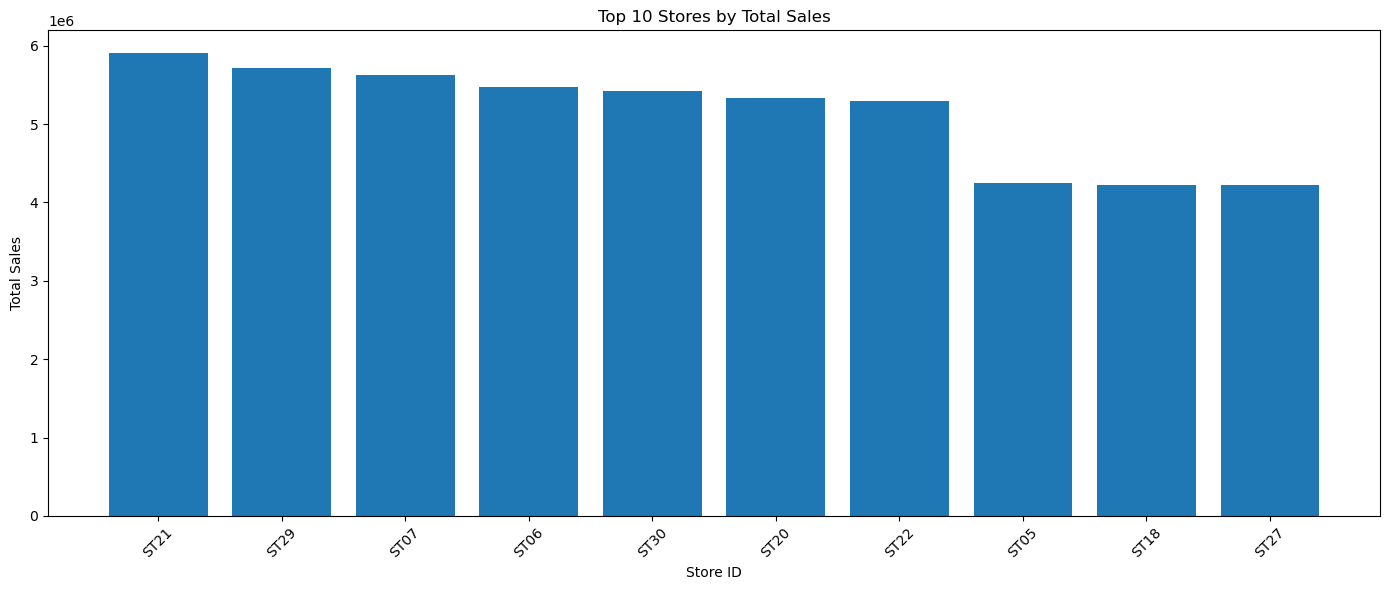

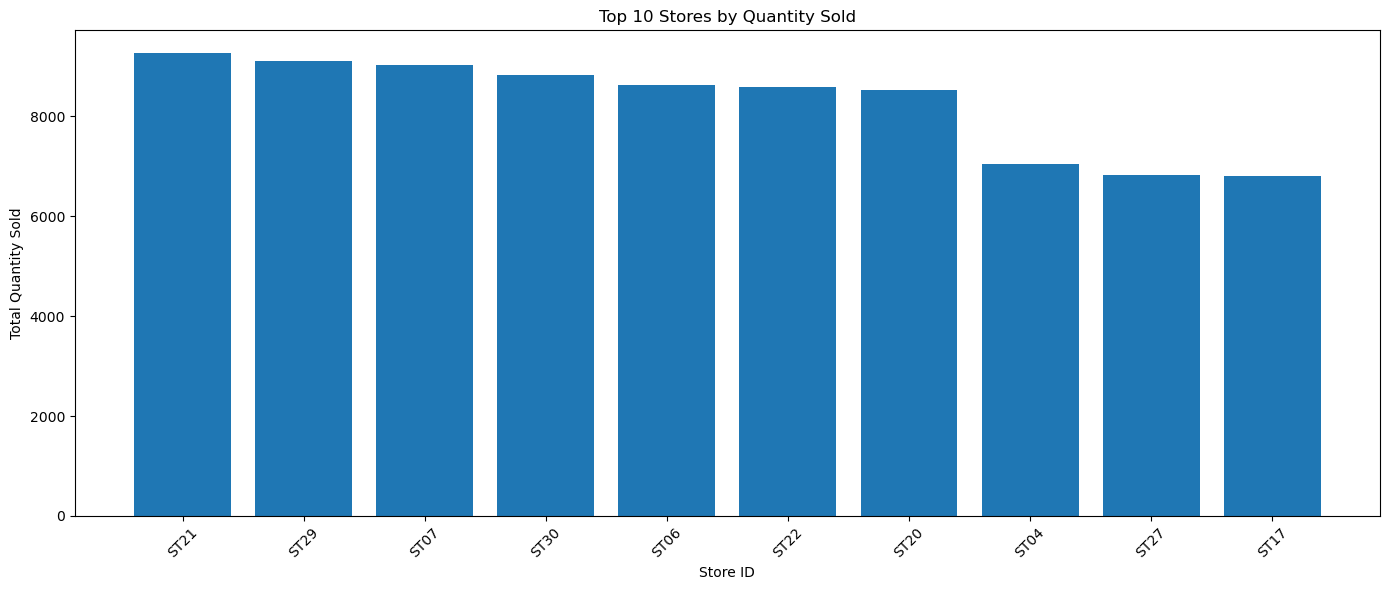


STEP 3.21 COMPLETED


In [56]:
# ============================================================
# STEP 3.21 - STORE-WISE SALES & QUANTITY ANALYSIS
# ============================================================

print("=" * 70)
print("STEP 3.21 - STORE-WISE SALES & QUANTITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Store-wise summary
# ------------------------------------------------------------

store_summary = (
    cleaned_sales
    .groupby("store_id")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique"),
        unique_skus=("sku_id", "nunique")
    )
    .reset_index()
)

# Average transaction value
store_summary["avg_transaction_value"] = (
    store_summary["total_sales"] /
    store_summary["transactions"]
)

# Sort by sales
store_summary = store_summary.sort_values(
    "total_sales",
    ascending=False
).reset_index(drop=True)

print("\n========== STORE-WISE SALES SUMMARY ==========")
print(store_summary.to_string(index=False))


# ------------------------------------------------------------
# 2. Top 10 stores by sales
# ------------------------------------------------------------

top_stores = store_summary.head(10)

print("\n========== TOP 10 STORES BY SALES ==========")
print(top_stores.to_string(index=False))


# ------------------------------------------------------------
# 3. Highest and lowest performing stores
# ------------------------------------------------------------

highest_store = store_summary.iloc[0]
lowest_store = store_summary.iloc[-1]

print("\n========== STORE INSIGHTS ==========")

print(
    f"Highest sales store: "
    f"{highest_store['store_id']} "
    f"(₹{highest_store['total_sales']:,.2f})"
)

print(
    f"Lowest sales store: "
    f"{lowest_store['store_id']} "
    f"(₹{lowest_store['total_sales']:,.2f})"
)


# ------------------------------------------------------------
# 4. Store-wise Sales Chart
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.bar(
    top_stores["store_id"].astype(str),
    top_stores["total_sales"]
)

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Store-wise Quantity Chart
# ------------------------------------------------------------

top_quantity_stores = (
    store_summary
    .sort_values("total_quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 6))

plt.bar(
    top_quantity_stores["store_id"].astype(str),
    top_quantity_stores["total_quantity"]
)

plt.title("Top 10 Stores by Quantity Sold")
plt.xlabel("Store ID")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("STEP 3.21 COMPLETED")
print("=" * 70)

In [57]:
# ============================================================
# STEP 3.22 - WEEKLY SKU DEMAND DATASET
# ============================================================

print("=" * 70)
print("STEP 3.22 - WEEKLY SKU DEMAND DATASET")
print("=" * 70)

# Make sure date is datetime
cleaned_sales["date"] = pd.to_datetime(cleaned_sales["date"])

# Create week start
cleaned_sales["week"] = (
    cleaned_sales["date"]
    .dt.to_period("W")
    .apply(lambda x: x.start_time)
)

# Weekly SKU demand
weekly_sku_demand = (
    cleaned_sales
    .groupby(["week", "sku_id"])
    .agg(
        demand=("quantity", "sum"),
        sales=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

# Sort
weekly_sku_demand = weekly_sku_demand.sort_values(
    ["sku_id", "week"]
).reset_index(drop=True)

print("\n========== WEEKLY SKU DEMAND ==========")
print(weekly_sku_demand.head(20))

print("\nDataset shape:")
print(weekly_sku_demand.shape)

print("\nNumber of unique SKUs:")
print(weekly_sku_demand["sku_id"].nunique())

print("\nNumber of weeks:")
print(weekly_sku_demand["week"].nunique())

print("\nWeek range:")
print(
    weekly_sku_demand["week"].min(),
    "to",
    weekly_sku_demand["week"].max()
)

print("\nMissing values:")
print(weekly_sku_demand.isnull().sum())

print("\n" + "=" * 70)
print("STEP 3.22 COMPLETED")
print("=" * 70)

STEP 3.22 - WEEKLY SKU DEMAND DATASET

========== WEEKLY SKU DEMAND ==========
         week    sku_id  demand    sales  transactions
0  2022-03-28  SKU00001       1   813.41             1
1  2022-06-13  SKU00001       2  1626.82             1
2  2022-07-18  SKU00001       3  2440.23             1
3  2023-01-16  SKU00001       2  1626.82             1
4  2023-04-10  SKU00001       5  4067.05             1
5  2023-05-15  SKU00001       1   813.41             1
6  2023-07-17  SKU00001       1   813.41             1
7  2023-07-31  SKU00001       1   813.41             1
8  2023-08-14  SKU00001       4  3253.64             2
9  2023-11-13  SKU00001       2  1626.82             1
10 2023-11-20  SKU00001       2  1626.82             2
11 2023-12-18  SKU00001       1   813.41             1
12 2024-01-01  SKU00001       2  1626.82             1
13 2024-03-25  SKU00001       2  1626.82             1
14 2024-08-05  SKU00001       1   813.41             1
15 2024-11-25  SKU00001       2  1626.82 

In [58]:
weekly_sku_demand = (
    cleaned_sales
    .groupby(['week', 'sku_id'], as_index=False)
    .agg(
        demand=('quantity', 'sum'),
        sales=('total_value', 'sum'),
        transactions=('receipt_id', 'nunique')
    )
)

print(weekly_sku_demand.head(20))
print("Shape:", weekly_sku_demand.shape)
print("Columns:", weekly_sku_demand.columns.tolist())
print(weekly_sku_demand.isnull().sum())

         week    sku_id  demand    sales  transactions
0  2021-12-27  SKU00190       2   290.84             1
1  2021-12-27  SKU00205       2   445.78             1
2  2021-12-27  SKU00232       1    96.13             1
3  2021-12-27  SKU00269       1   170.73             1
4  2021-12-27  SKU00278       2  3615.68             1
5  2021-12-27  SKU00305       2   986.22             1
6  2021-12-27  SKU00423       1   109.08             1
7  2021-12-27  SKU00500       1  1264.58             1
8  2021-12-27  SKU00520       3   141.12             1
9  2021-12-27  SKU00639       2  1707.18             1
10 2021-12-27  SKU00643       2   981.56             1
11 2021-12-27  SKU00694       2   359.42             1
12 2021-12-27  SKU00713       3   475.95             1
13 2021-12-27  SKU00726       2  1949.34             1
14 2021-12-27  SKU00728       1  3555.73             1
15 2021-12-27  SKU00908       1  2108.67             1
16 2021-12-27  SKU00953       5  1369.95             3
17 2021-12

WEEKLY DEMAND TREND
  week_start  total_quantity
0 2021-12-27             207
1 2022-01-03             618
2 2022-01-10             688
3 2022-01-17             693
4 2022-01-24             689
5 2022-01-31             745
6 2022-02-07             706
7 2022-02-14             788
8 2022-02-21             573
9 2022-02-28             841

Total weeks: 210

WEEKLY DEMAND STATISTICS
Average weekly demand: 895.40
Minimum weekly demand: 207.00
Maximum weekly demand: 1315.00


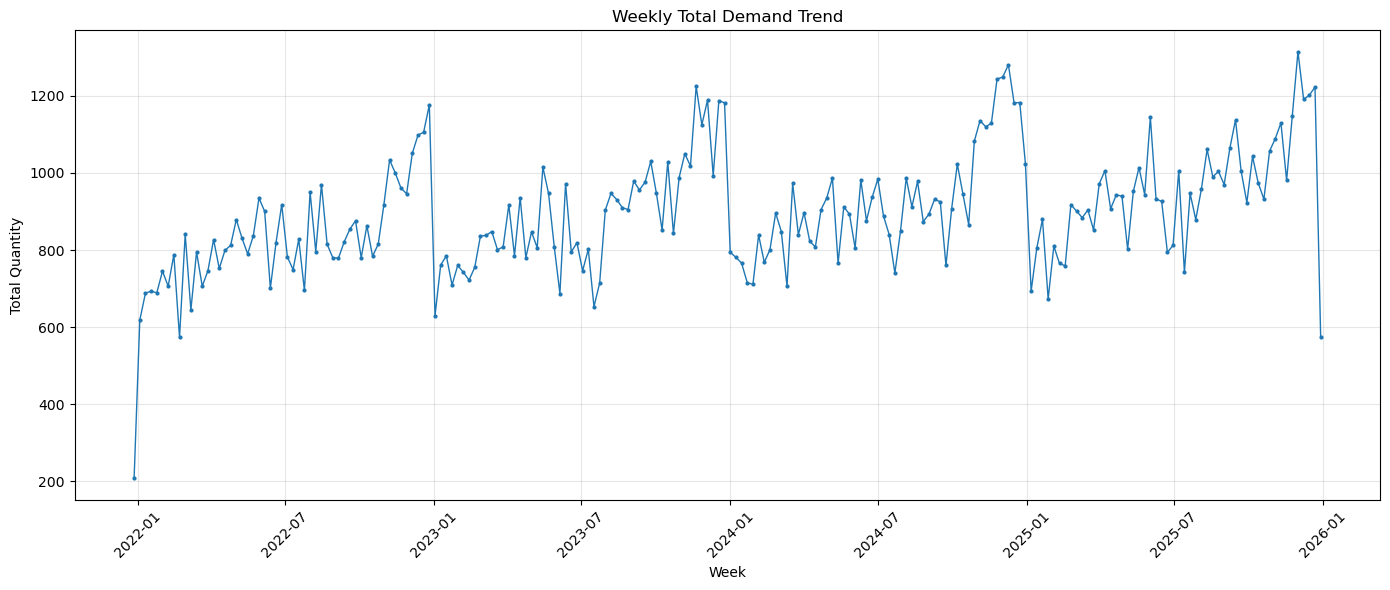


WEEK OF YEAR SEASONALITY
    week_of_year  total_quantity
0              1          727.40
1              2          730.75
2              3          762.25
3              4          748.25
4              5          722.25
5              6          774.25
6              7          760.75
7              8          722.00
8              9          872.75
9             10          807.75
10            11          808.25
11            12          846.00
12            13          811.50
13            14          903.25
14            15          841.50
15            16          862.50
16            17          860.00
17            18          900.25
18            19          856.50
19            20          880.75


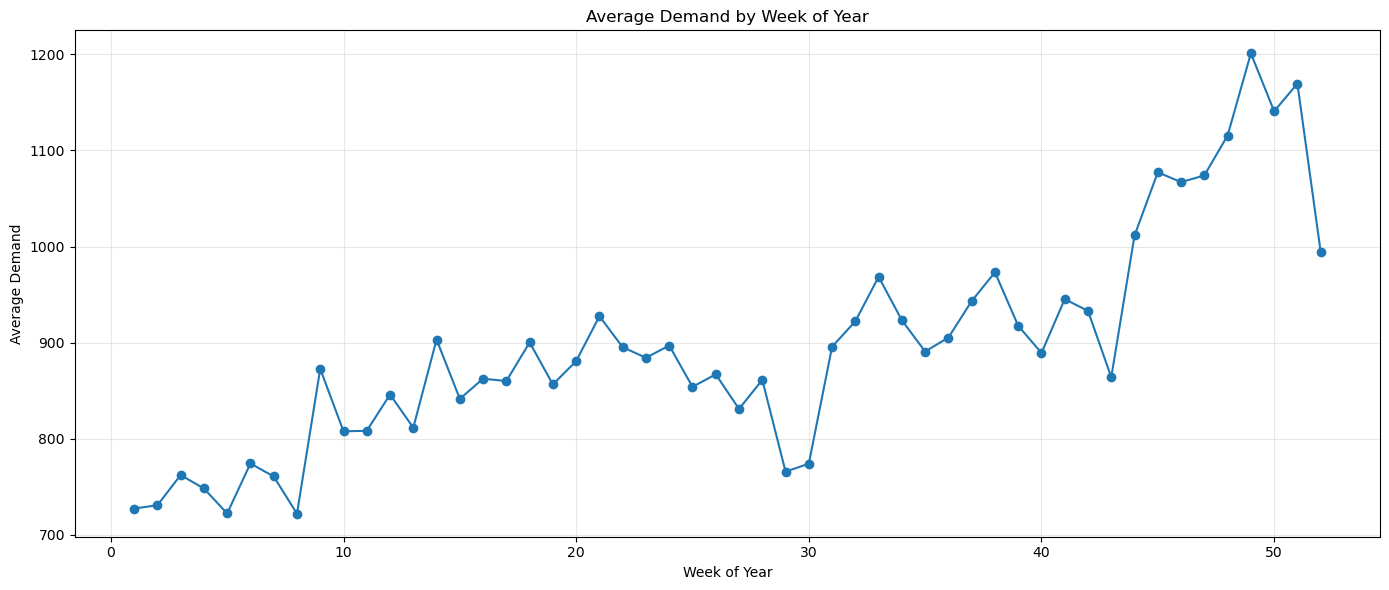


SEASONALITY INSIGHTS
Highest average-demand week: Week 49 (1201.00)
Lowest average-demand week: Week 8 (722.00)

STEP 3.23 COMPLETED


In [59]:
# ============================================================
# STEP 3.23 - WEEKLY DEMAND TREND & SEASONALITY ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure week_start is datetime
weekly_demand['week_start'] = pd.to_datetime(weekly_demand['week_start'])

# ------------------------------------------------------------
# 1. Weekly total demand
# ------------------------------------------------------------

weekly_total = (
    weekly_demand
    .groupby('week_start', as_index=False)['total_quantity']
    .sum()
    .sort_values('week_start')
)

print("=" * 70)
print("WEEKLY DEMAND TREND")
print("=" * 70)

print(weekly_total.head(10))
print("\nTotal weeks:", len(weekly_total))


# ------------------------------------------------------------
# 2. Basic statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("WEEKLY DEMAND STATISTICS")
print("=" * 70)

print(
    f"Average weekly demand: "
    f"{weekly_total['total_quantity'].mean():.2f}"
)

print(
    f"Minimum weekly demand: "
    f"{weekly_total['total_quantity'].min():.2f}"
)

print(
    f"Maximum weekly demand: "
    f"{weekly_total['total_quantity'].max():.2f}"
)


# ------------------------------------------------------------
# 3. Plot weekly demand trend
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_total['week_start'],
    weekly_total['total_quantity'],
    marker='o',
    markersize=2,
    linewidth=1
)

plt.title("Weekly Total Demand Trend")
plt.xlabel("Week")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Create week-of-year for seasonality analysis
# ------------------------------------------------------------

weekly_total['week_of_year'] = (
    weekly_total['week_start']
    .dt.isocalendar()
    .week
    .astype(int)
)

seasonality = (
    weekly_total
    .groupby('week_of_year', as_index=False)['total_quantity']
    .mean()
)

print("\n" + "=" * 70)
print("WEEK OF YEAR SEASONALITY")
print("=" * 70)

print(seasonality.head(20))


# ------------------------------------------------------------
# 5. Seasonality plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    seasonality['week_of_year'],
    seasonality['total_quantity'],
    marker='o',
    linewidth=1.5
)

plt.title("Average Demand by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Demand")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Highest and Lowest seasonal weeks
# ------------------------------------------------------------

highest_week = seasonality.loc[
    seasonality['total_quantity'].idxmax()
]

lowest_week = seasonality.loc[
    seasonality['total_quantity'].idxmin()
]

print("\n" + "=" * 70)
print("SEASONALITY INSIGHTS")
print("=" * 70)

print(
    f"Highest average-demand week: "
    f"Week {int(highest_week['week_of_year'])} "
    f"({highest_week['total_quantity']:.2f})"
)

print(
    f"Lowest average-demand week: "
    f"Week {int(lowest_week['week_of_year'])} "
    f"({lowest_week['total_quantity']:.2f})"
)

print("\nSTEP 3.23 COMPLETED")

In [1]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
C:\Users\Deepak\Desktop\FORESIGHT PROJECT\notebooks

Files in current folder:
['.ipynb_checkpoints', '01_data_quality_eda.ipynb', '02_baseline_forecast.ipynb', '03_model_risk.ipynb']


In [2]:
from pathlib import Path

# Project folder
project_folder = Path.cwd().parent

# Find sales_100k.csv anywhere inside the project
files = list(project_folder.rglob("sales_100k.csv"))

print("Files found:")
for file in files:
    print(file)

Files found:
C:\Users\Deepak\Desktop\FORESIGHT PROJECT\data\processed\sales_100k.csv


In [3]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:


NameError: name 'df' is not defined

In [4]:
# ==========================================
# STEP 3.24 - TOP-SELLING SKUs
# ==========================================

top_selling_skus = (
    df.groupby('sku_id')
      .agg(
          total_quantity=('quantity', 'sum'),
          total_sales=('total_value', 'sum')
      )
      .sort_values('total_sales', ascending=False)
      .head(10)
      .reset_index()
)

print("=" * 60)
print("TOP-SELLING SKUs")
print("=" * 60)

print(top_selling_skus.to_string(index=False))

NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Top-selling SKUs
top_selling_skus = (
    df.groupby("sku_id")
      .agg(
          total_quantity=("quantity", "sum"),
          total_sales=("total_value", "sum")
      )
      .sort_values("total_sales", ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    top_selling_skus.index.astype(str),
    top_selling_skus["total_sales"]
)

plt.title("Top 10 Selling SKUs")
plt.xlabel("SKU ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Low / slow-moving SKUs

low_moving_skus = (
    df.groupby("sku_id")
      .agg(
          total_quantity=("quantity", "sum"),
          total_sales=("total_value", "sum")
      )
      .sort_values(
          ["total_quantity", "total_sales"],
          ascending=[True, True]
      )
      .head(10)
)

print("=" * 60)
print("LOW / SLOW-MOVING SKUs")
print("=" * 60)

print(low_moving_skus)

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    low_moving_skus.index.astype(str),
    low_moving_skus["total_quantity"]
)

plt.title("Low / Slow-Moving SKUs")
plt.xlabel("SKU ID")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EDA Conclusion

## Overall Findings

The exploratory data analysis provided a clear understanding of the sales data, including sales performance, quantity trends, demand patterns, top-selling SKUs, and slow-moving SKUs.

### Key Conclusions

1. The dataset contains transaction-level sales information including date, receipt, store, SKU, customer, quantity, unit price, total value, channel, discount percentage, and promo information.

2. Sales performance was analyzed across different time periods to identify overall sales trends and demand patterns.

3. The analysis identified the top-selling SKUs based on total quantity sold and total sales value.

4. SKU04321 was identified as the strongest-performing SKU in the analyzed data, with the highest total quantity sold and the highest total sales value among the top-selling SKUs.

5. Several SKUs showed very low sales quantities and can be classified as low/slow-moving products. These products may require further investigation regarding demand, pricing, promotions, or inventory management.

6. The EDA also highlighted differences in sales behavior across the available sales dimensions and provided useful information for future forecasting and business decision-making.

## Final Takeaway

The EDA successfully transformed the raw sales data into meaningful business insights. The identified sales trends, demand patterns, top-performing products, and slow-moving products can be used as a foundation for further sales forecasting, inventory planning, and business strategy.


# EDA Insight Memo

## Business Summary

The exploratory data analysis of the sales dataset was performed to understand sales performance, customer demand, product performance, and potential inventory-related issues.

## Key Business Insights

### 1. Top-Selling Products

The analysis identified the highest-performing SKUs based on quantity sold and total sales.

SKU04321 was the strongest-performing SKU in the analyzed results, with:

- Total Quantity Sold: 12,306
- Total Sales: 1,114,153.51

Other high-performing SKUs were also identified and can be prioritized for inventory availability and demand forecasting.

### 2. Low / Slow-Moving Products

Several SKUs recorded very low quantities sold. These products may represent slow-moving inventory.

Examples include SKUs with only 1–2 units sold during the analyzed period.

These products should be reviewed to determine whether their low demand is related to pricing, lack of promotion, limited availability, or naturally low customer demand.

### 3. Business Recommendations

- Maintain sufficient inventory for consistently high-performing SKUs.
- Closely monitor demand for top-selling SKUs to reduce stock-out risk.
- Review slow-moving products before replenishing inventory.
- Consider targeted promotions or discounts for suitable slow-moving products.
- Use the identified demand patterns as inputs for future sales forecasting.
- Continue monitoring product-level sales performance regularly.

## Conclusion

The EDA provides a strong foundation for understanding the sales business and making data-driven decisions. The insights from product performance and demand analysis can be used in the next stage of the project for forecasting, inventory planning, and business optimization.
